<a href="https://colab.research.google.com/github/Yseokjun/2026-2-BDA-/blob/main/10w_data_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [ ]:
plt.rcParams['figure.figsize'] = (5,4)

In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 66.5 MB/s eta 0:00:00


In [ ]:
import sys
if 'pydataset' not in sys.modules:
  !pip install pydataset
from pydataset import data
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [ ]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
iris.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [ ]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [ ]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [ ]:
display_side_by_side(iris.head(), iris.tail())


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [ ]:
display_series_side_by_side(iris['Petal.Length'][:5], iris.Species.value_counts())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [ ]:
display_series_side_by_side(iris['Petal.Length'][:5].to_frame(), iris.Species.value_counts().to_frame())

AttributeError: 'DataFrame' object has no attribute 'name'

[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


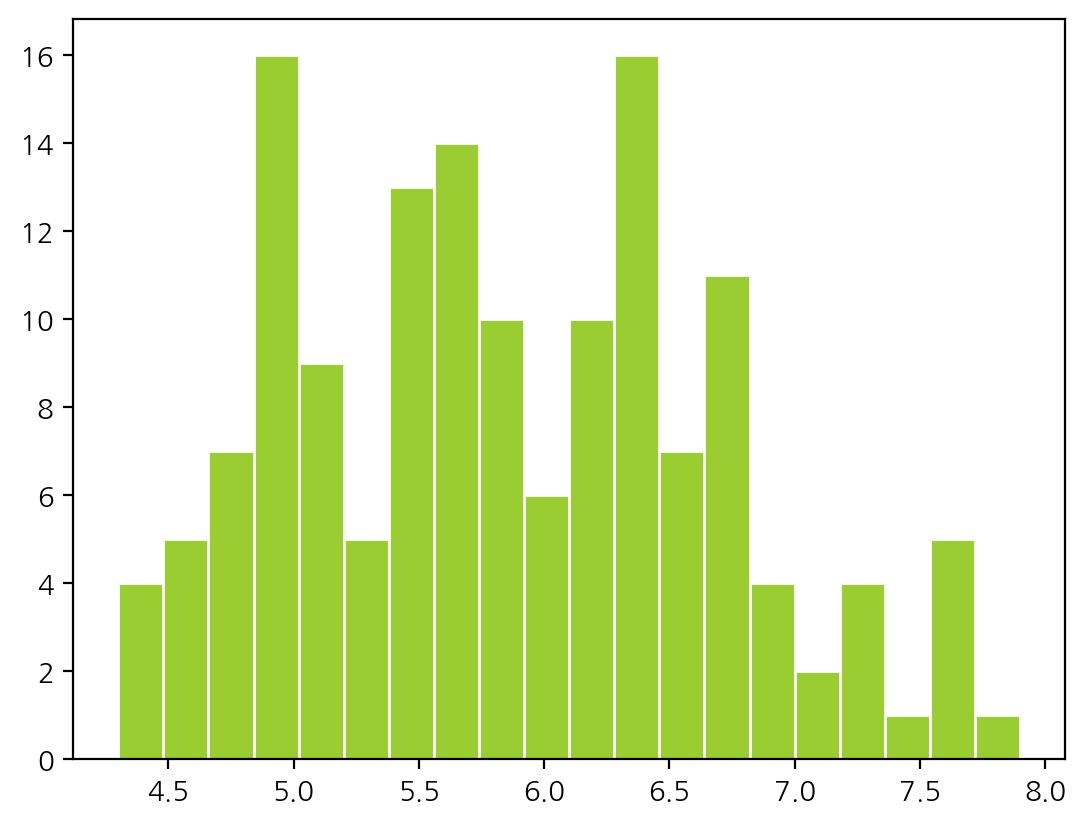

In [ ]:
n, bins, patches = plt.hist(iris['Sepal.Length'], bins = 20, color = 'yellowgreen', edgecolor = 'white')

print(n)
print(bins)
print(patches)

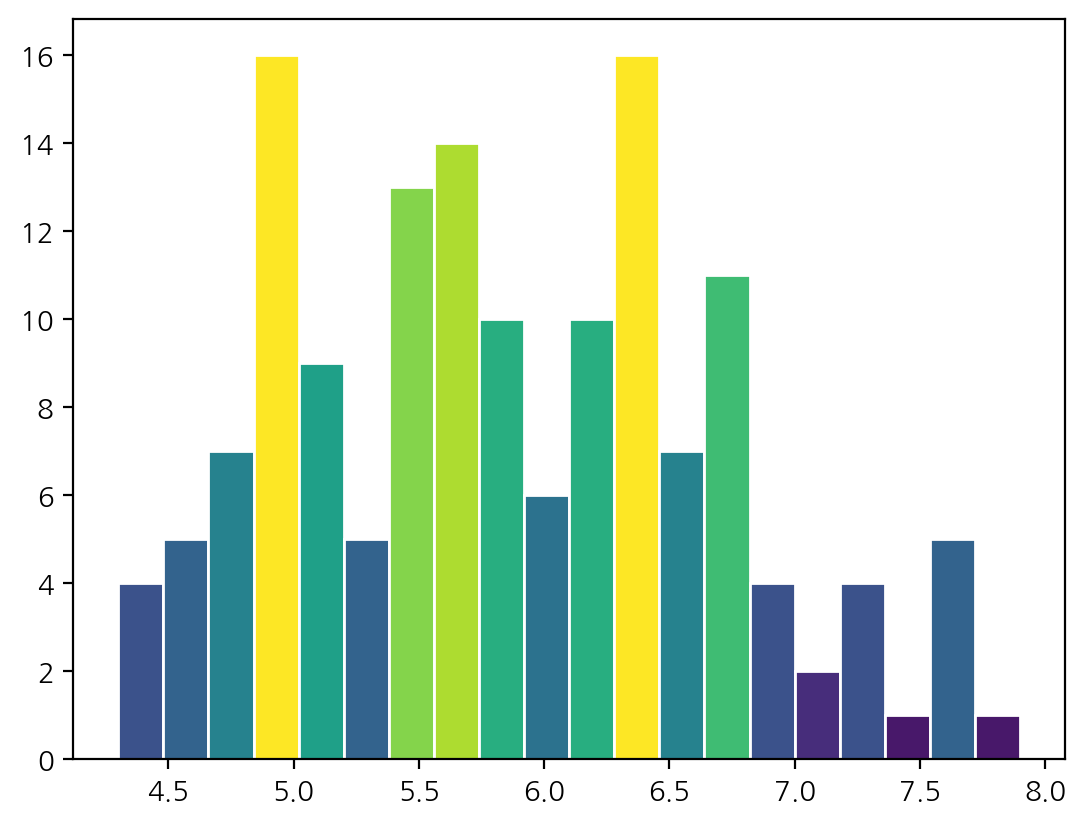

In [ ]:
n, bins, patches = plt.hist(iris['Sepal.Length'],
                            bins = 20,
                            color = 'yellowgreen',
                            edgecolor = 'white')
for i in range(len(patches)):
  patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))
plt.show()

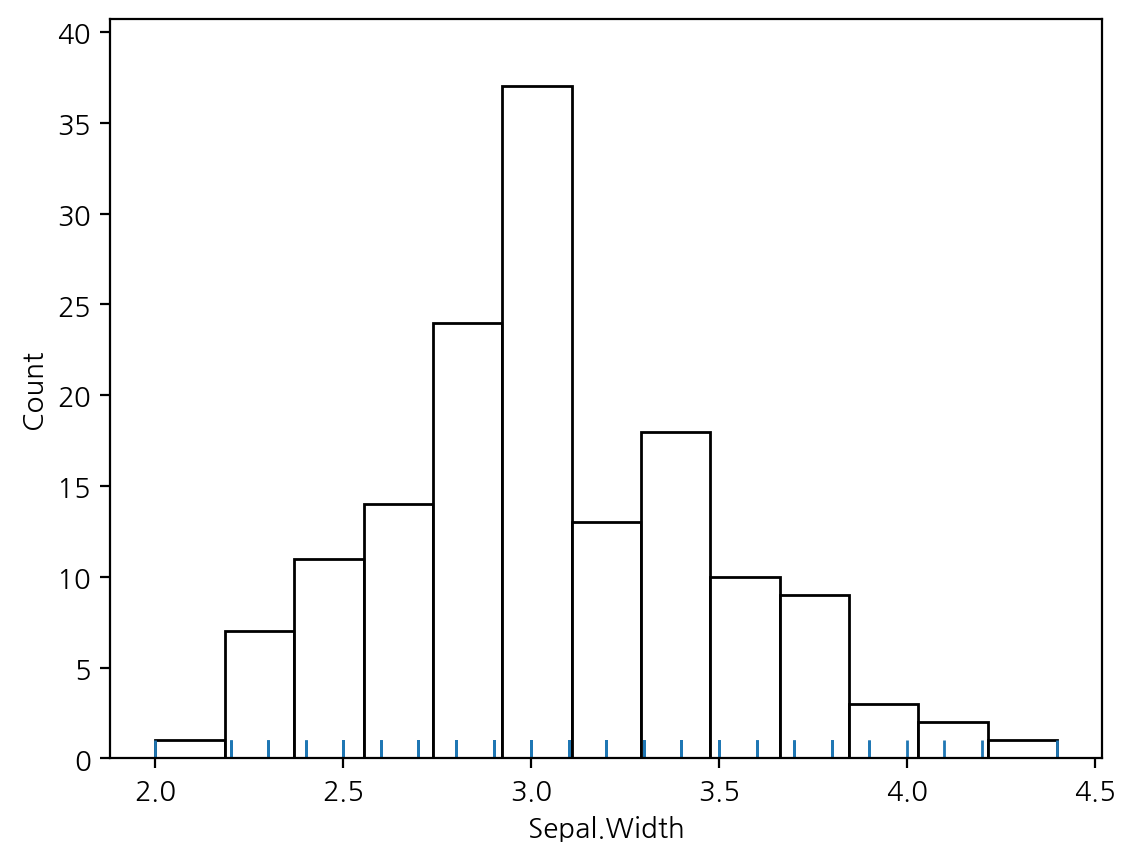

In [ ]:
import seaborn as sns
sns.histplot(data=iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data=iris, x= iris['Sepal.Width']);

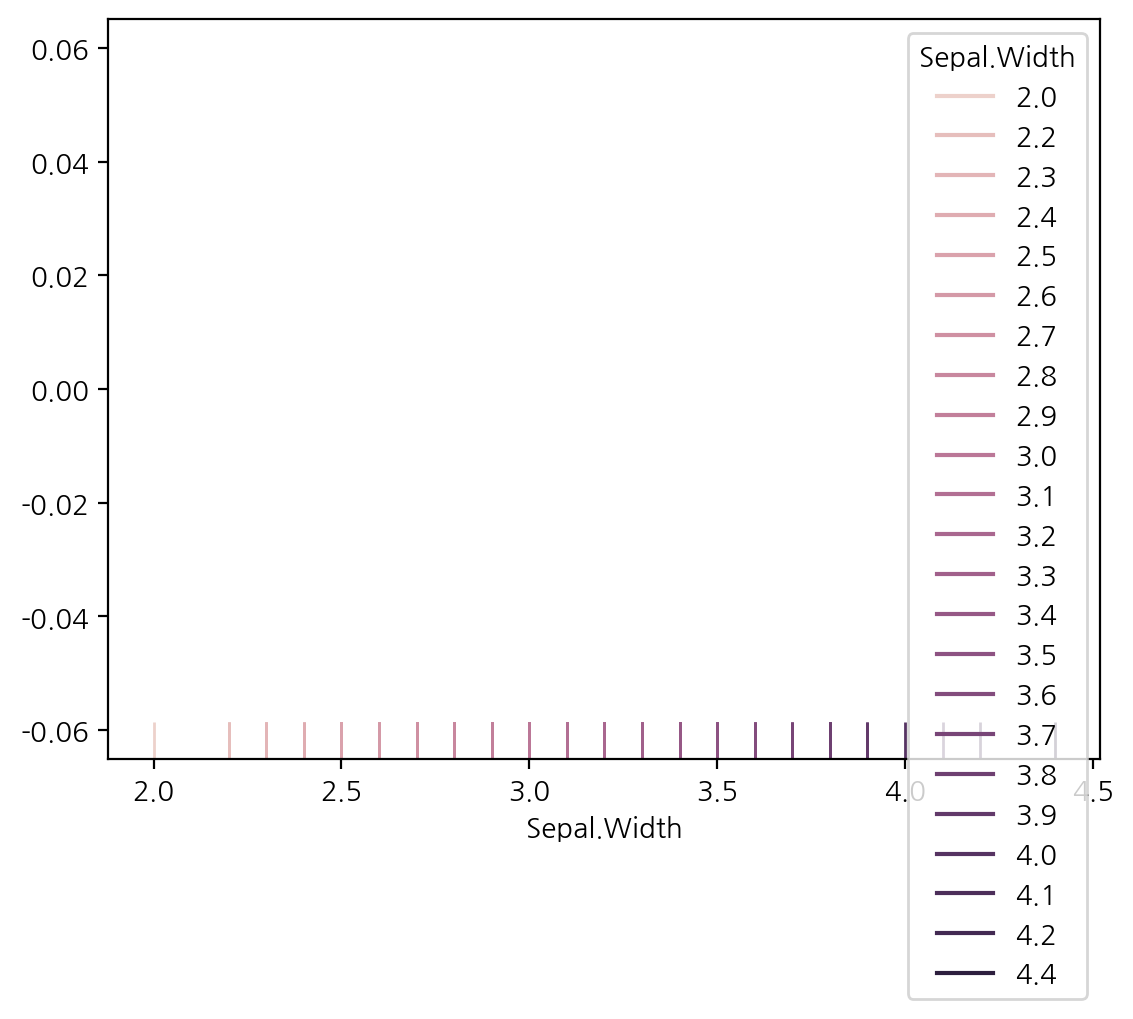

In [ ]:
sns.rugplot(data= iris, x = iris['Sepal.Width'],
            height = 0.05, hue = 'Sepal.Width');

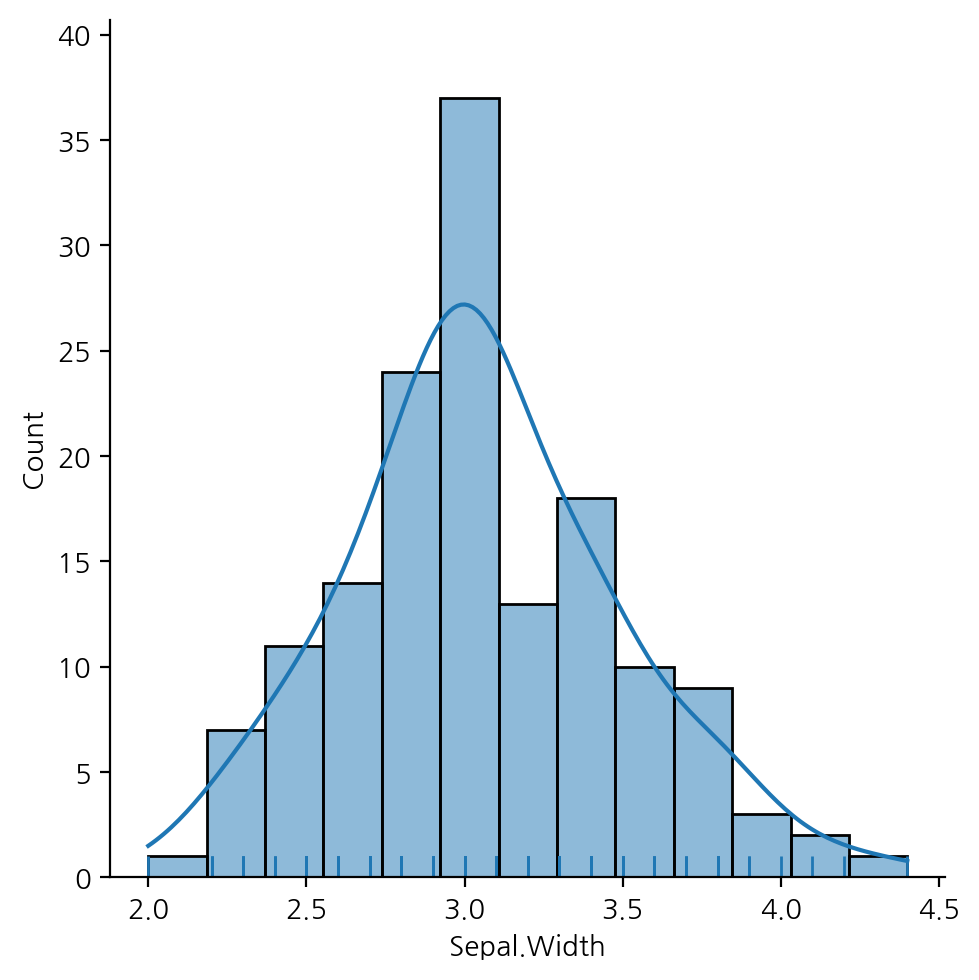

In [ ]:
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True);

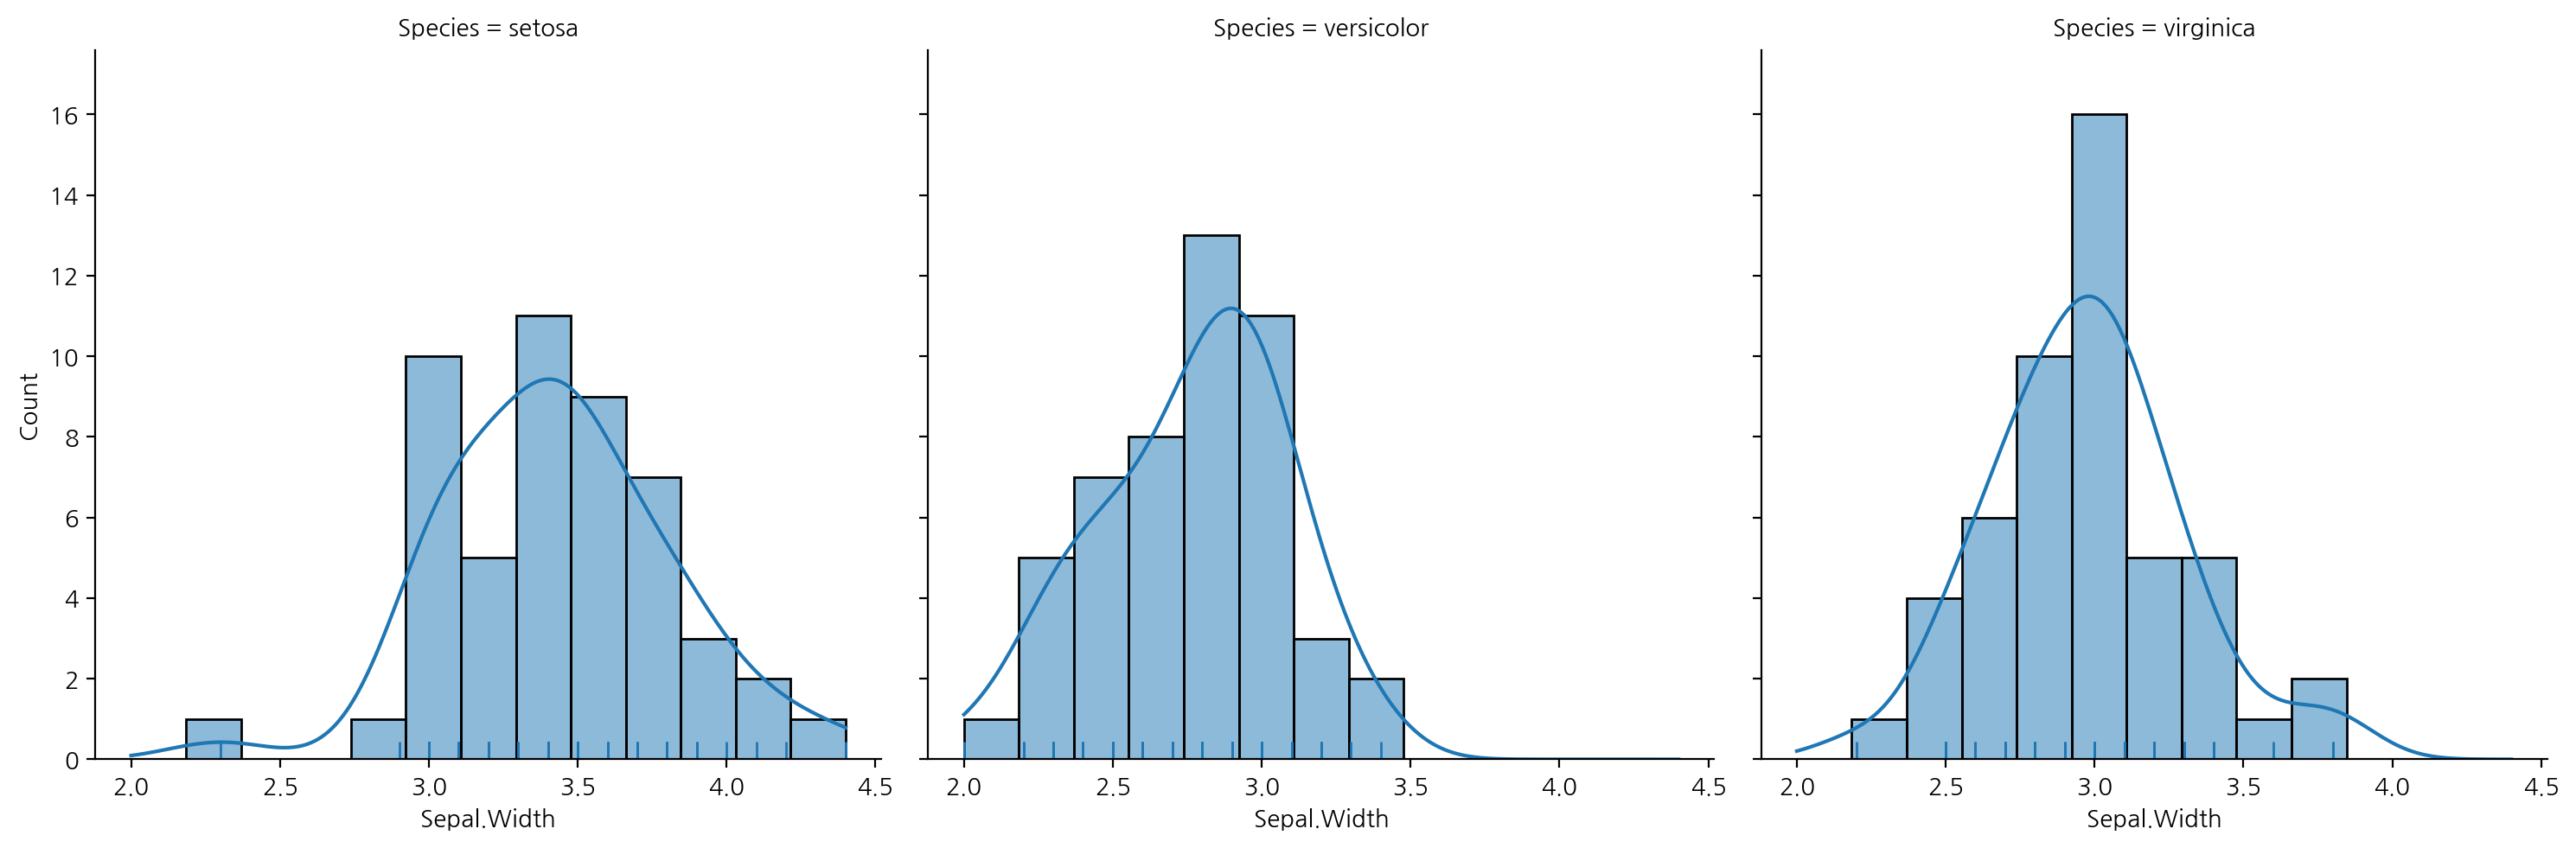

In [ ]:
sns.displot(data = iris, x = iris['Sepal.Width'], col="Species", kde=True, rug=True);

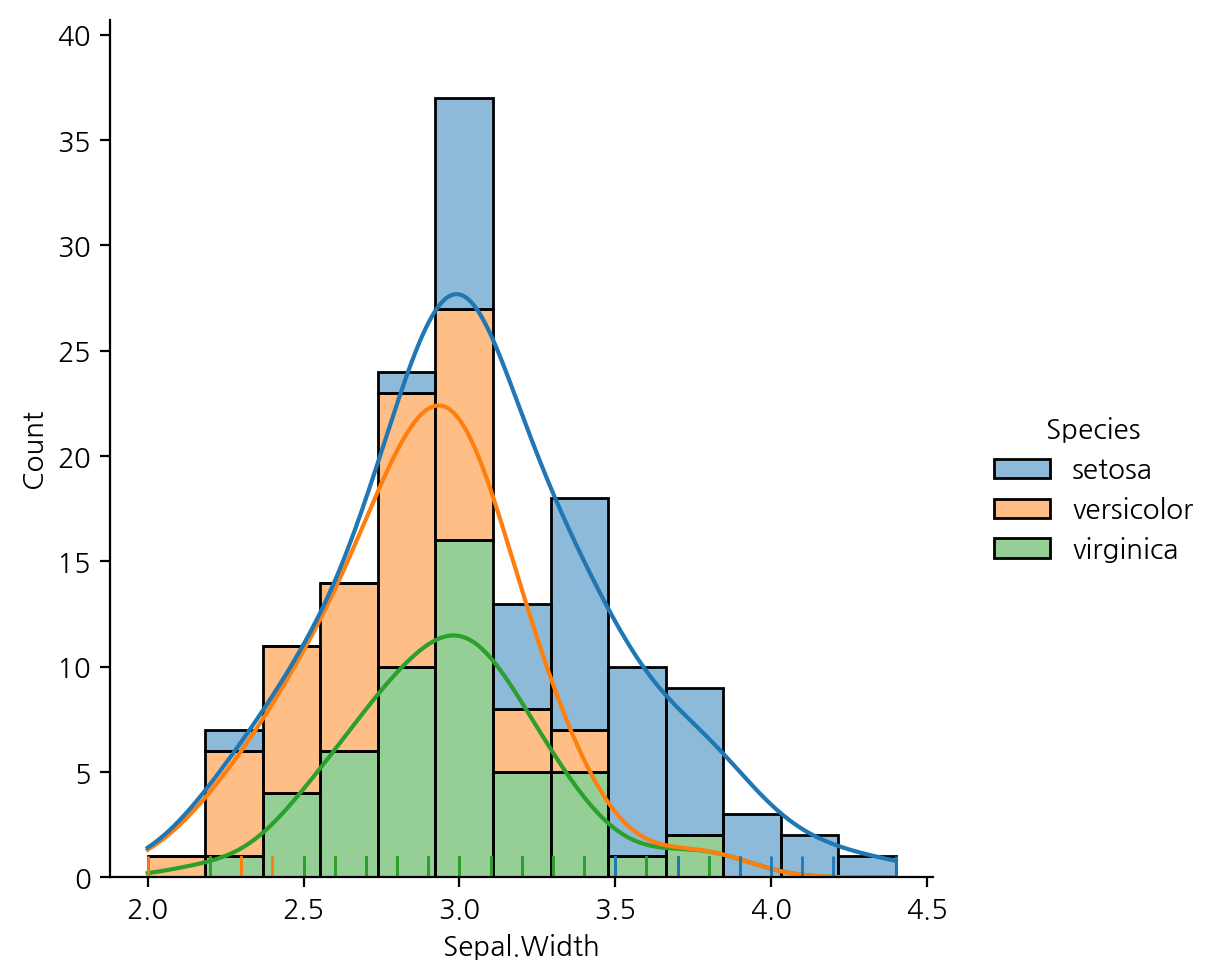

In [ ]:
sns.displot(data = iris, x = iris["Sepal.Width"] , kde = True, rug=True, multiple  = "stack", hue = "Species");

([<matplotlib.patches.Wedge at 0x7ea621c9b920>,
 [Text(1.0461621649530053, 0.3399187029582827, 'orange'),
  Text(0.33991865722907993, 1.0461621798113232, ' apples'),
  Text(-1.046162235191088, 0.33991848678762215, 'banana'),
  Text(0.33991884014588697, -1.0461621203780394, 'cherries')])

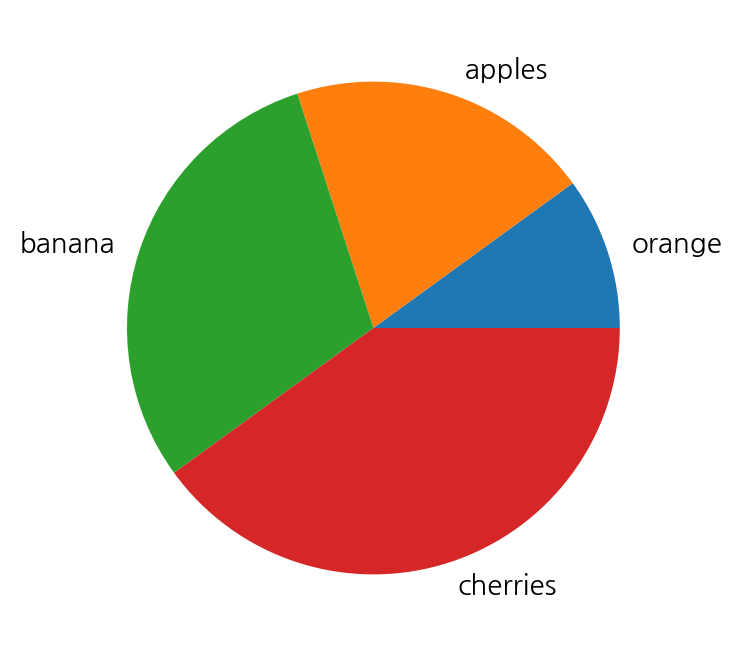

In [ ]:
fruits = [ "orange", " apples", "banana" , "cherries"]
plt.pie([10,20,30,40], labels = fruits)

In [ ]:
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [ ]:
mtc.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [ ]:
mtc.tail()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8
Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.6,1,1,4,2


In [ ]:
mtc.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [ ]:
mtc.cyl.value_counts().sort_index()

,count
cyl,
4,11
6,7
8,14


In [ ]:
mtc.cyl.value_counts().sort_index().index

Index([4, 6, 8], dtype='int64', name='cyl')

In [ ]:
txt = [str(i) + '기통' for i in mtc.cyl.value_counts().sort_index().index]
txt

['4기통', '6기통', '8기통']

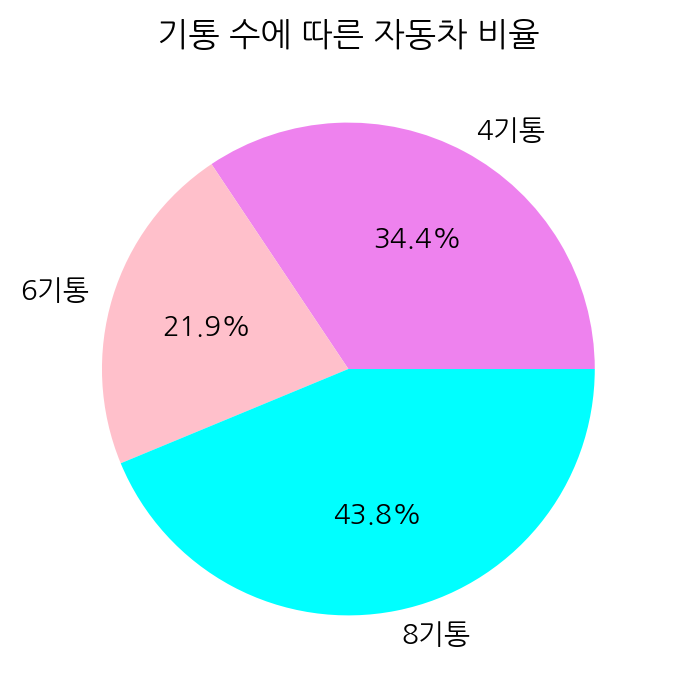

In [ ]:
plt.pie(mtc.cyl.value_counts().sort_index(),
colors = ["violet", "pink", "aqua"],
autopct='%.1f%%', labels = txt)
plt.title("기통 수에 따른 자동차 비율");

In [ ]:
mtc.gear.value_counts().sort_index()

,count
gear,
3,15
4,12
5,5


In [ ]:
labels = [str(i) + '기어' for i in mtc.gear.value_counts().sort_index().index]
labels

['3기어', '4기어', '5기어']

In [ ]:
colors = sns.color_palette("Accent", len(labels))
colors

[(0.4980392156862745, 0.788235294117647, 0.4980392156862745),
 (0.7450980392156863, 0.6823529411764706, 0.8313725490196079),
 (0.9921568627450981, 0.7529411764705882, 0.5254901960784314)]

In [ ]:
colors = sns.color_palette("Accent", len(labels))
colors

[(0.4980392156862745, 0.788235294117647, 0.4980392156862745),
 (0.7450980392156863, 0.6823529411764706, 0.8313725490196079),
 (0.9921568627450981, 0.7529411764705882, 0.5254901960784314)]

In [ ]:
colors = sns.color_palette("Set1", len(labels))
colors

[(0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)]

In [ ]:
colors = sns.color_palette("Set2",7)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451)]

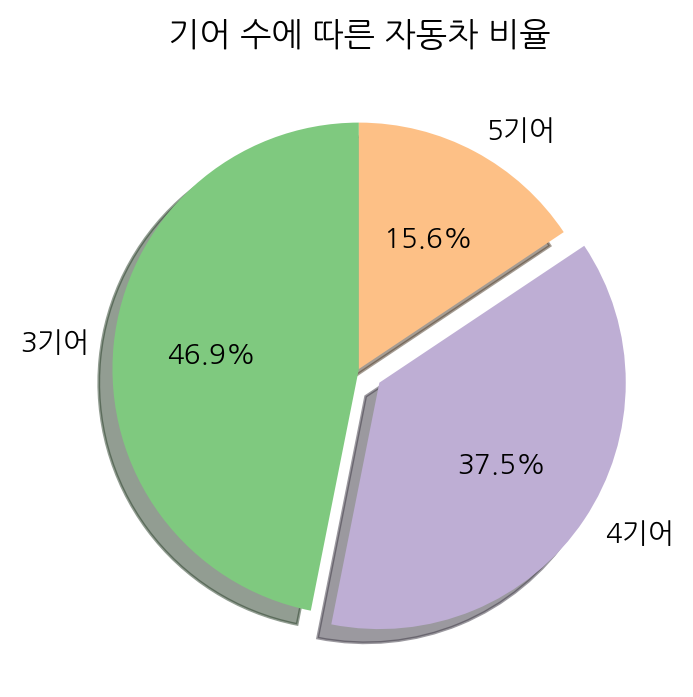

In [ ]:
colors = sns.color_palette('Accent', len(txt))
plt.pie(mtc.gear.value_counts().sort_index(), colors=colors, explode= [0, .1, 0],
        shadow = True, startangle = 90, autopct = '%.1f%%', labels= labels)
plt.title("기어 수에 따른 자동차 비율");

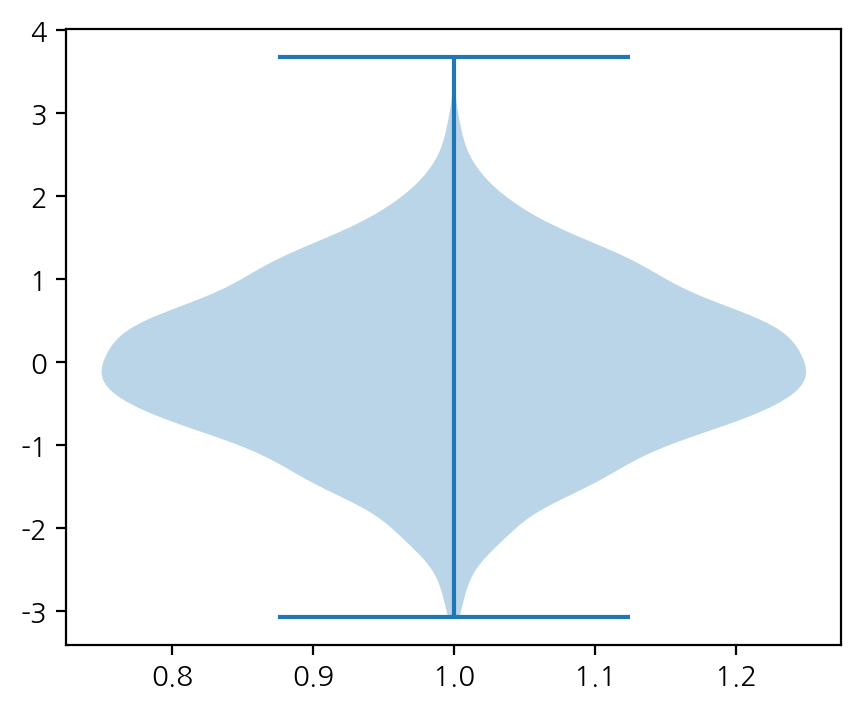

In [ ]:
data =  np.random.randn(2000)
plt.violinplot(data);

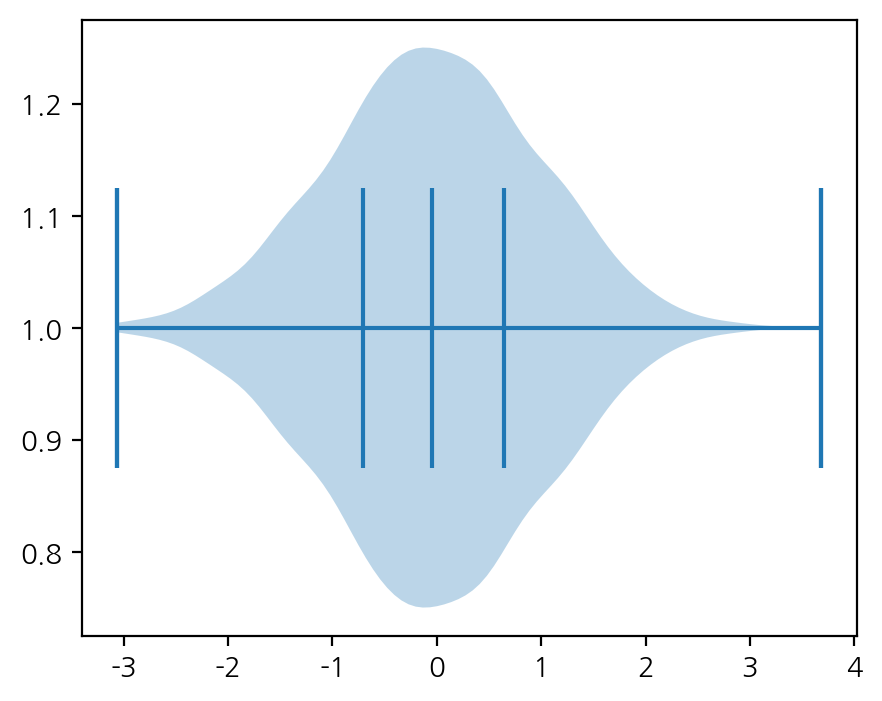

In [ ]:
plt.violinplot(data, quantiles = [0, .25, .5, .75, 1], vert=False);

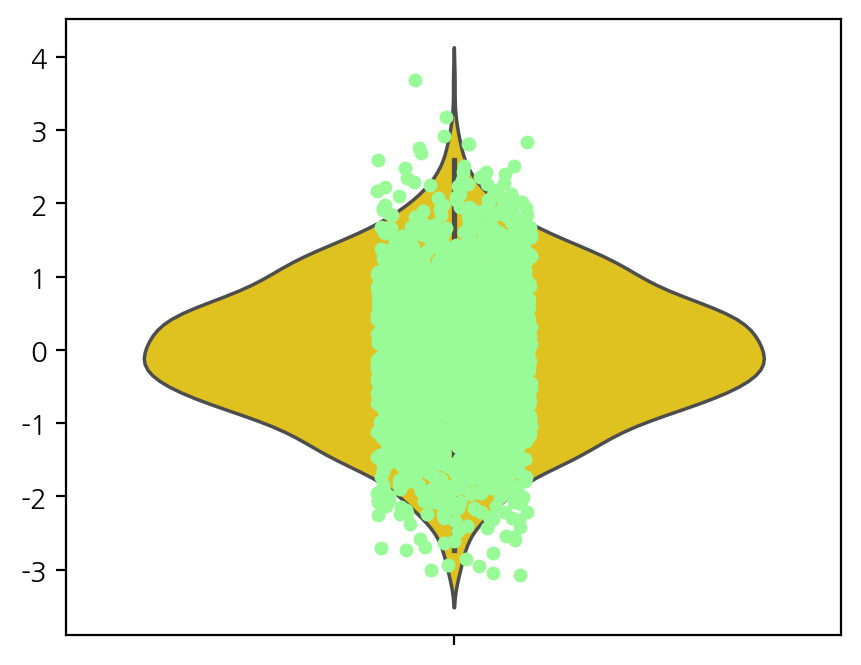

In [ ]:
sns.violinplot(data, color='gold');
sns.stripplot(data, color = 'palegreen');

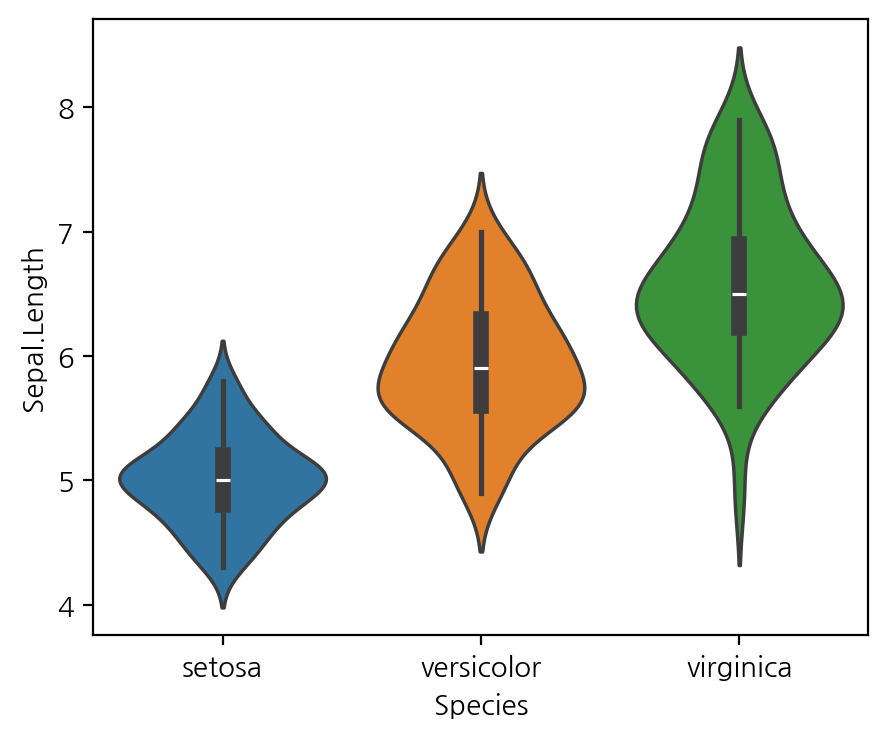

In [ ]:
sns.violinplot(iris, x="Species" , y = "Sepal.Length" , hue = "Species");

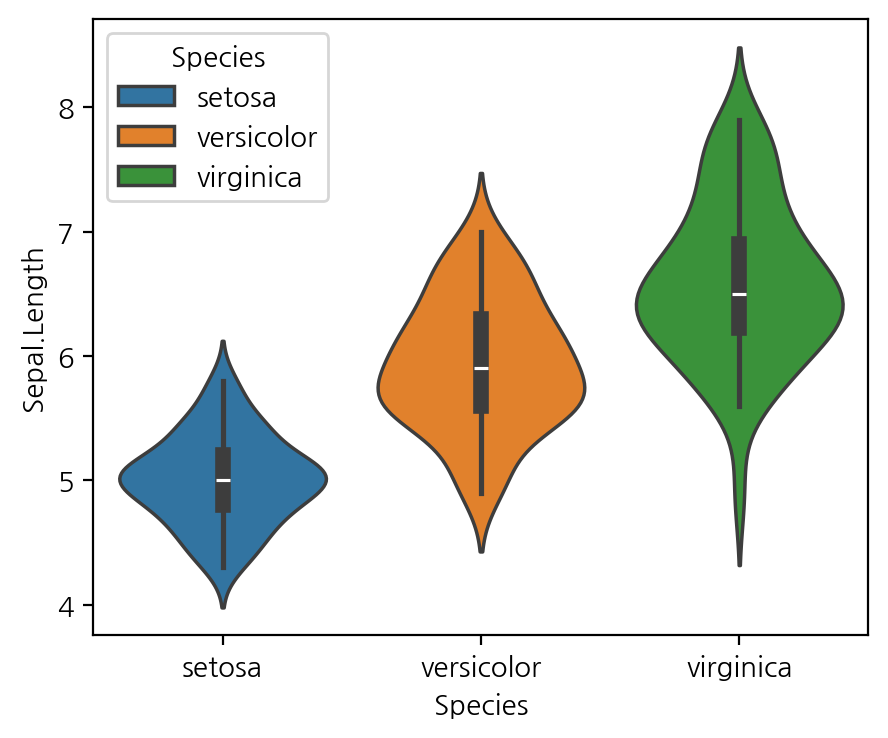

In [ ]:
sns.violinplot(iris, x="Species" , y = "Sepal.Length" , hue = "Species", legend = 'full');

In [ ]:
mincars = mtc.iloc[:, :4]
mincars.head()

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175


In [ ]:
print(mtc.columns[:4])
print(mtc.columns[:4].to_list())

Index(['mpg', 'cyl', 'disp', 'hp'], dtype='object')
['mpg', 'cyl', 'disp', 'hp']


In [ ]:
mincars = mtc[mtc.columns[:4].to_list()]
mincars.head(3)

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93


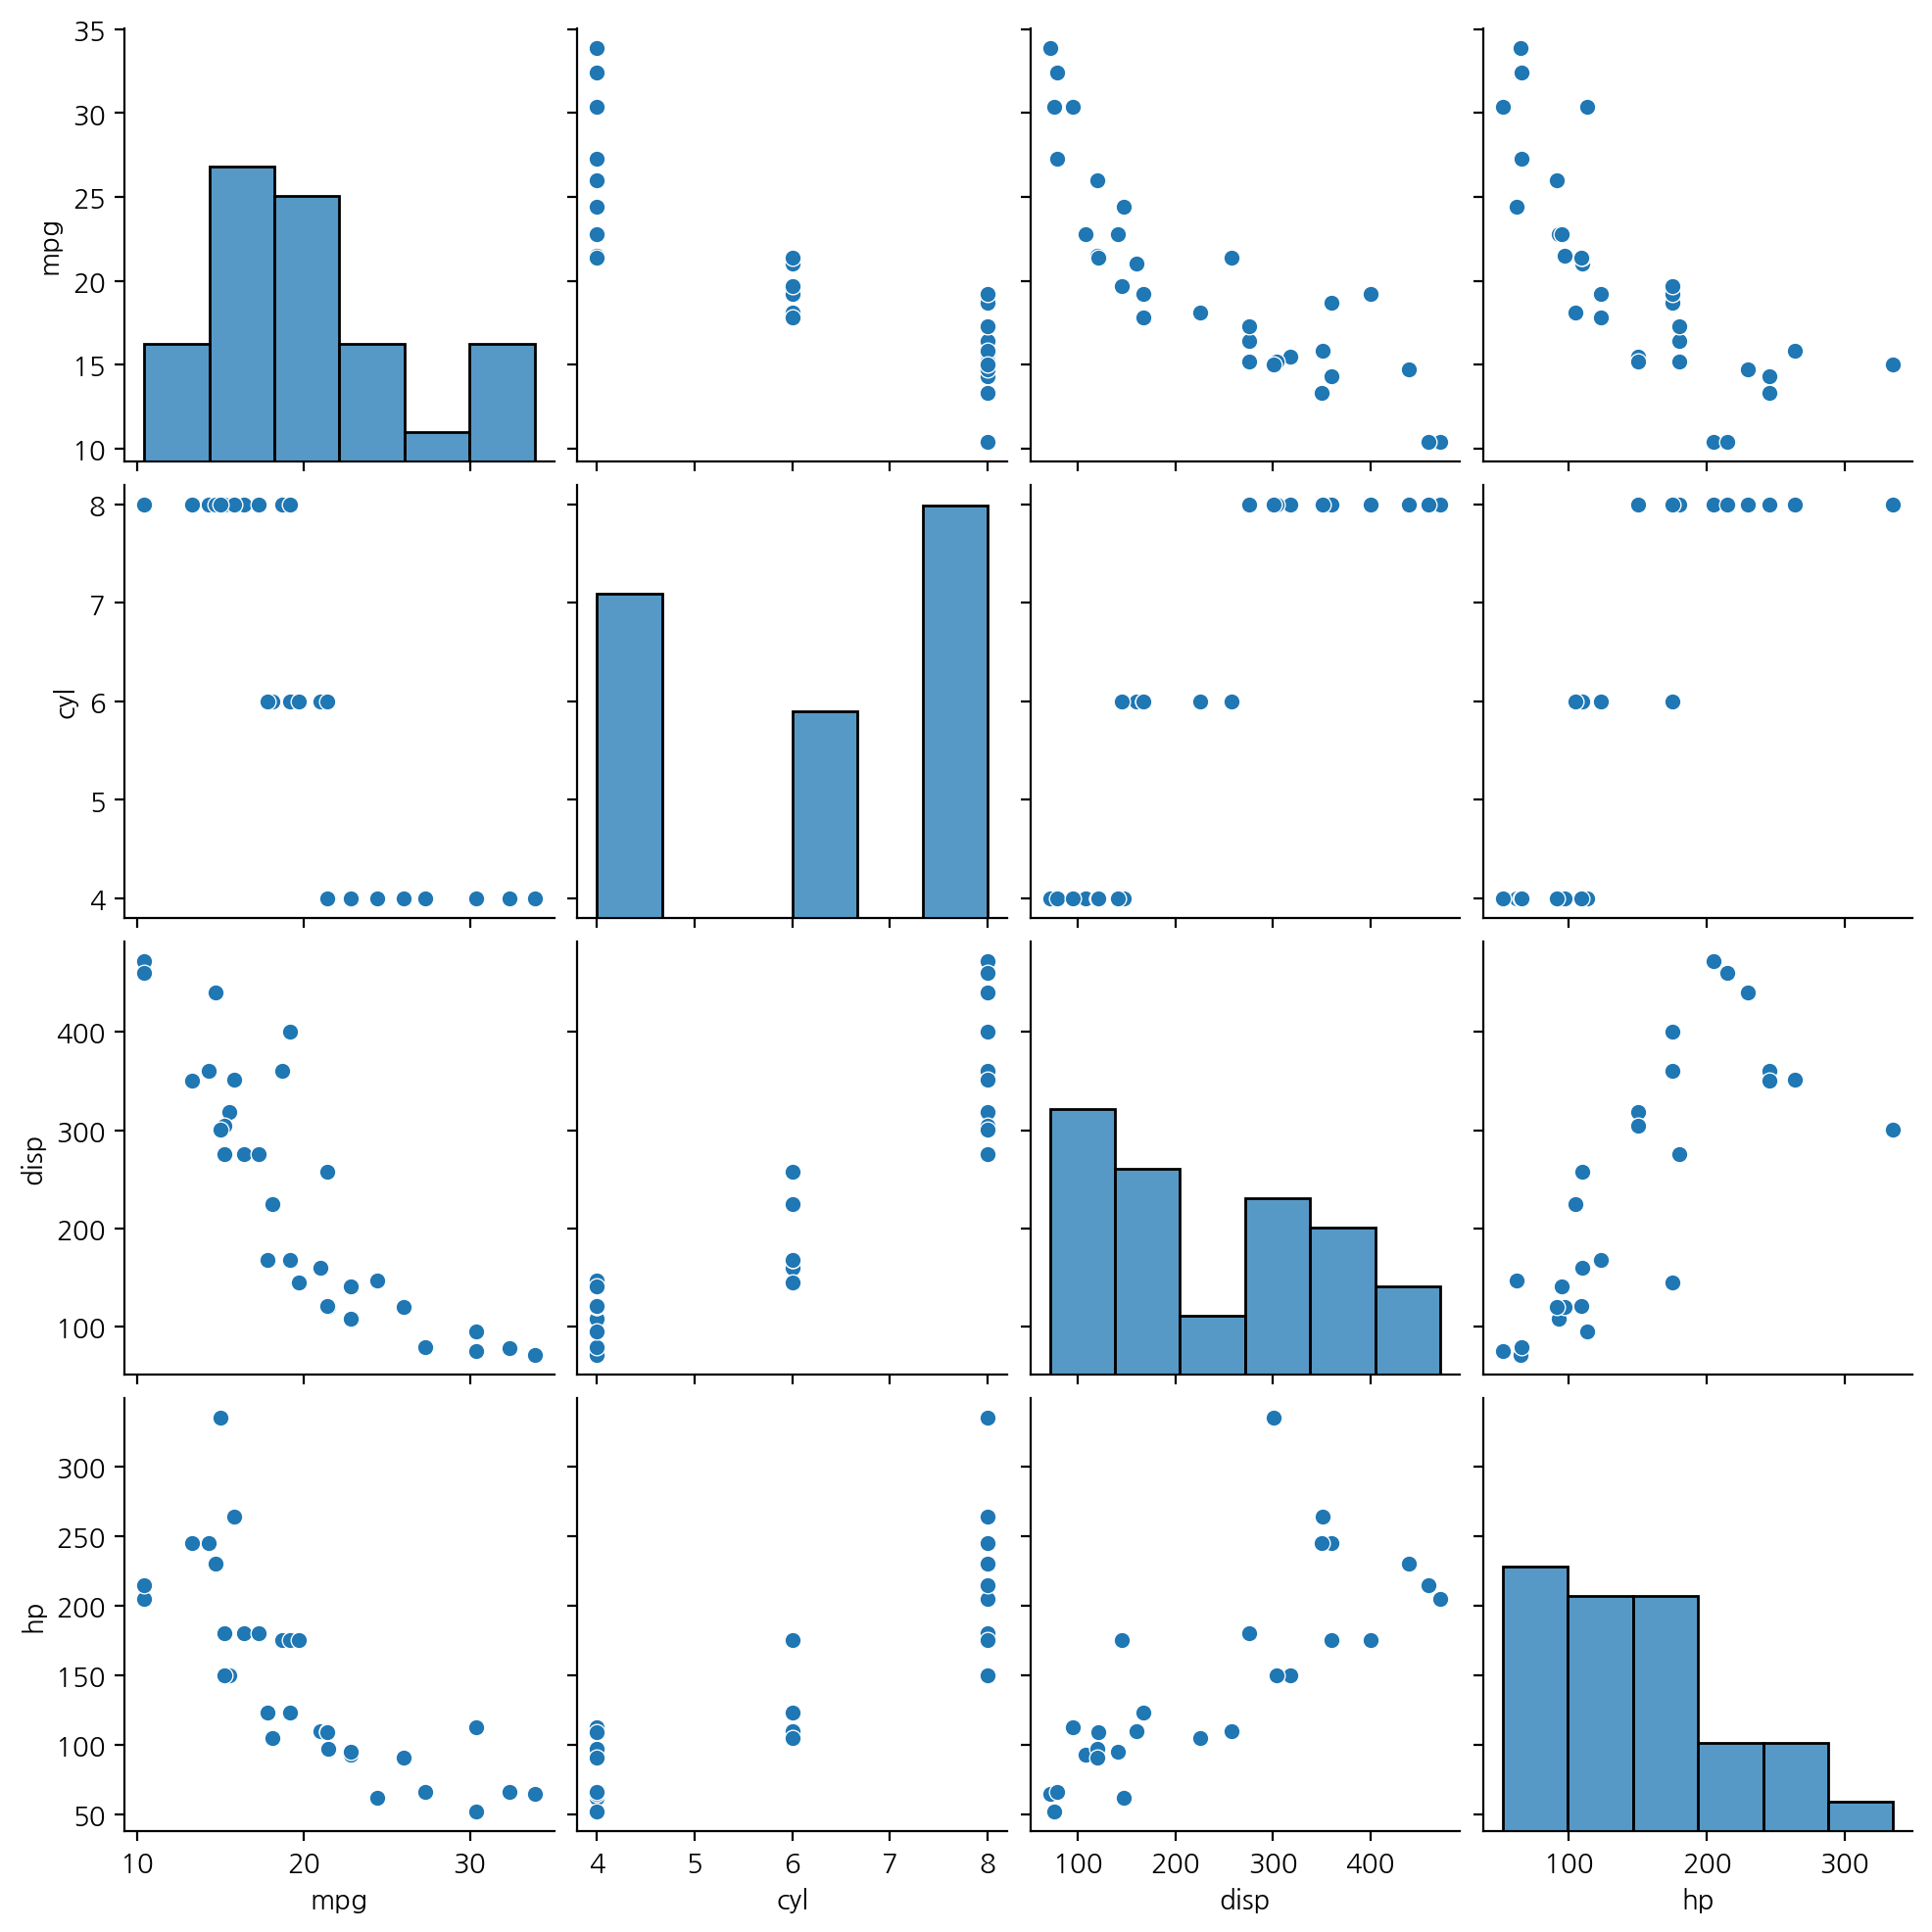

In [ ]:
sns.pairplot(mincars);

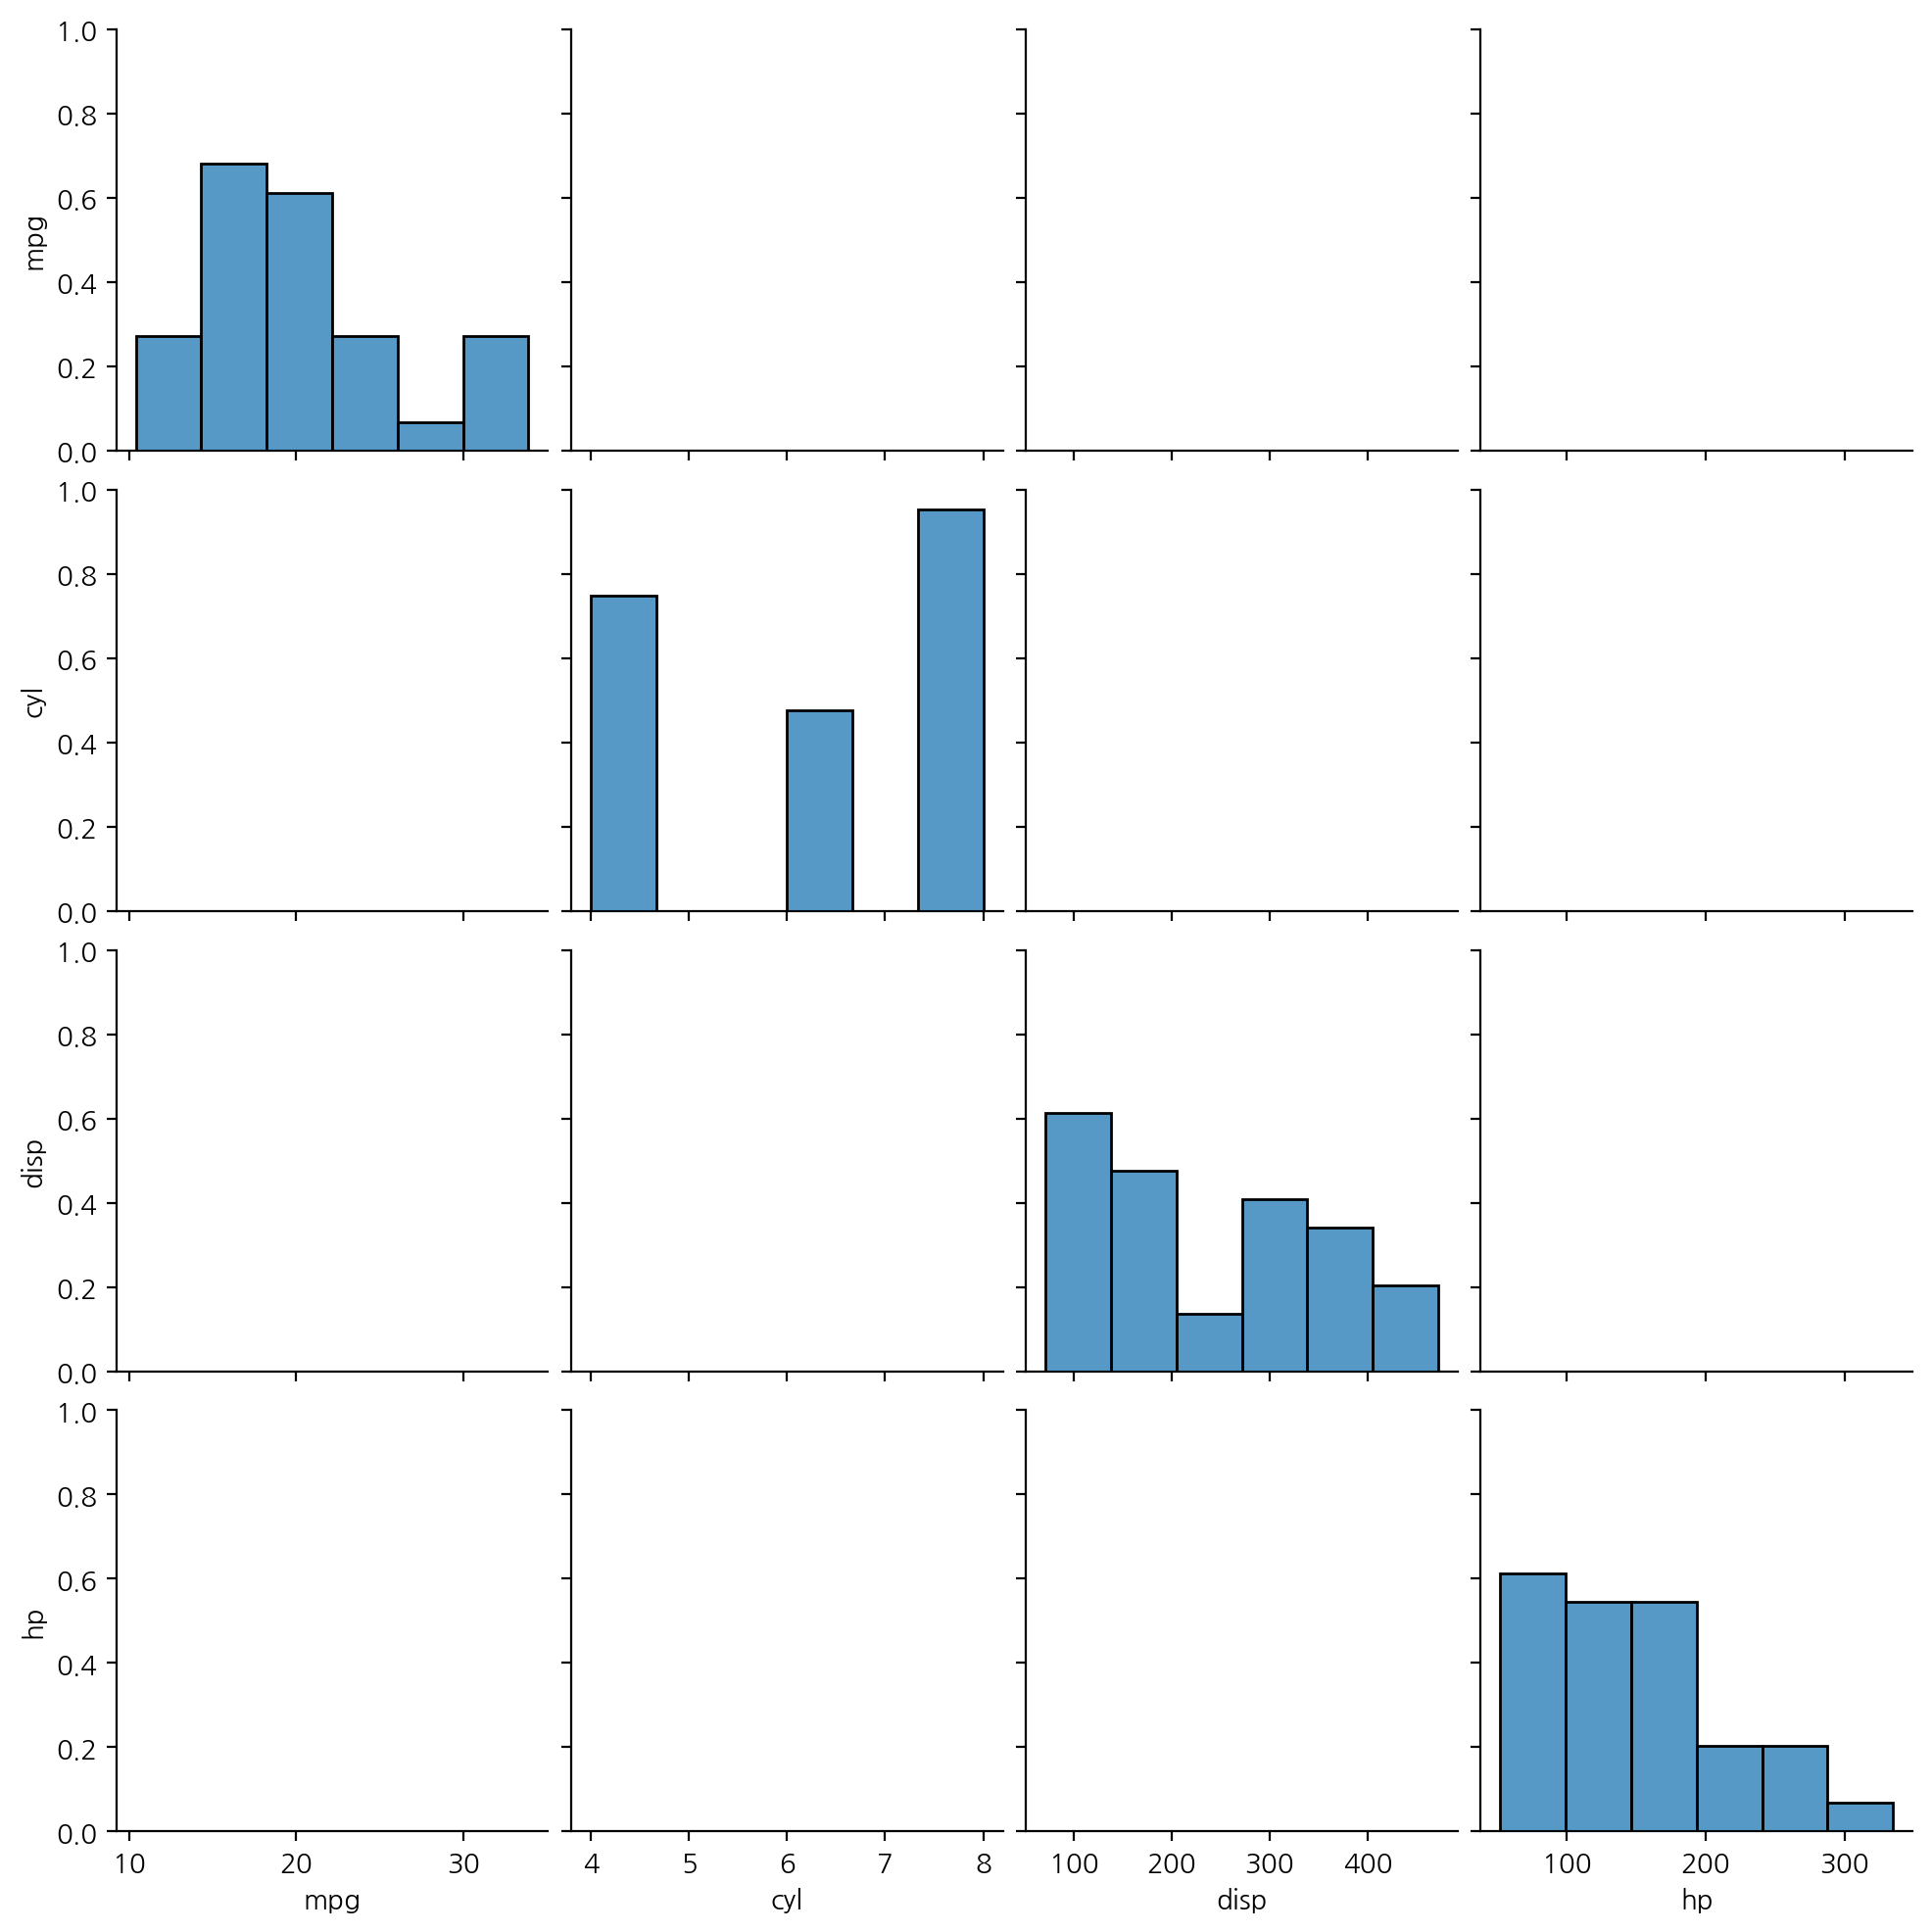

In [ ]:
sns.pairplot(mincars, kind =' reg');

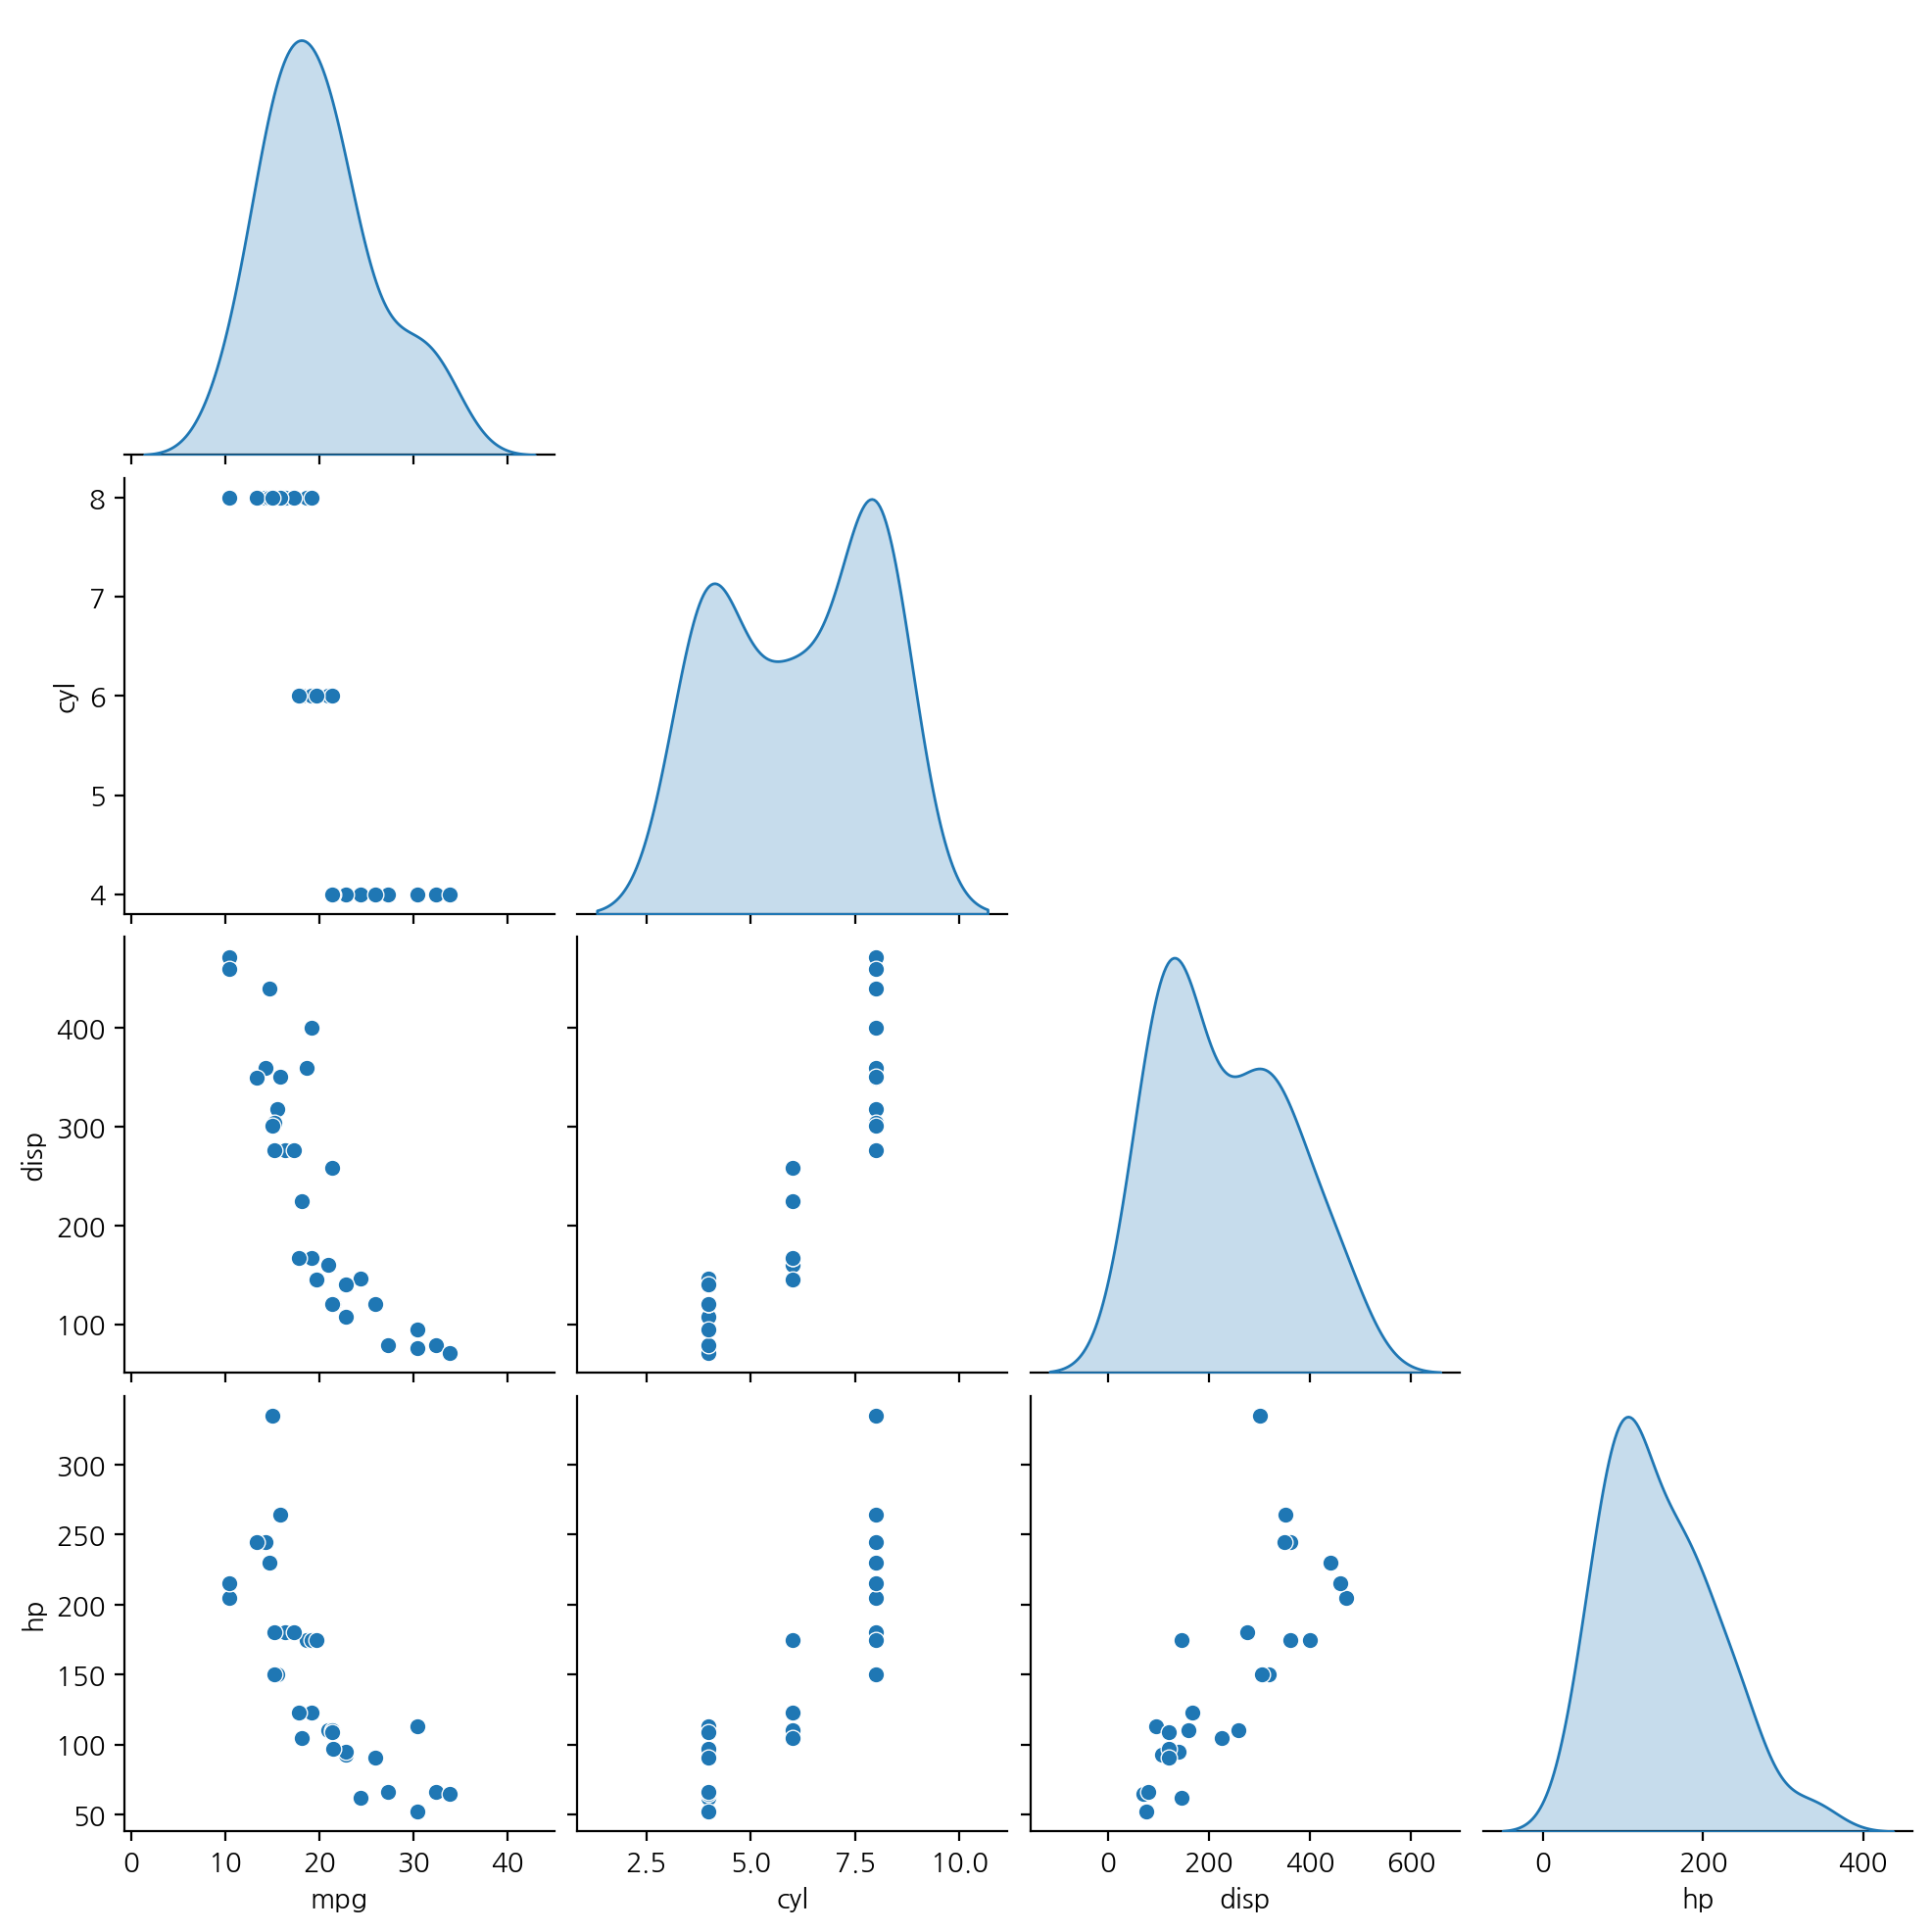

In [ ]:
sns.pairplot(mincars, diag_kind ='kde', corner=True);

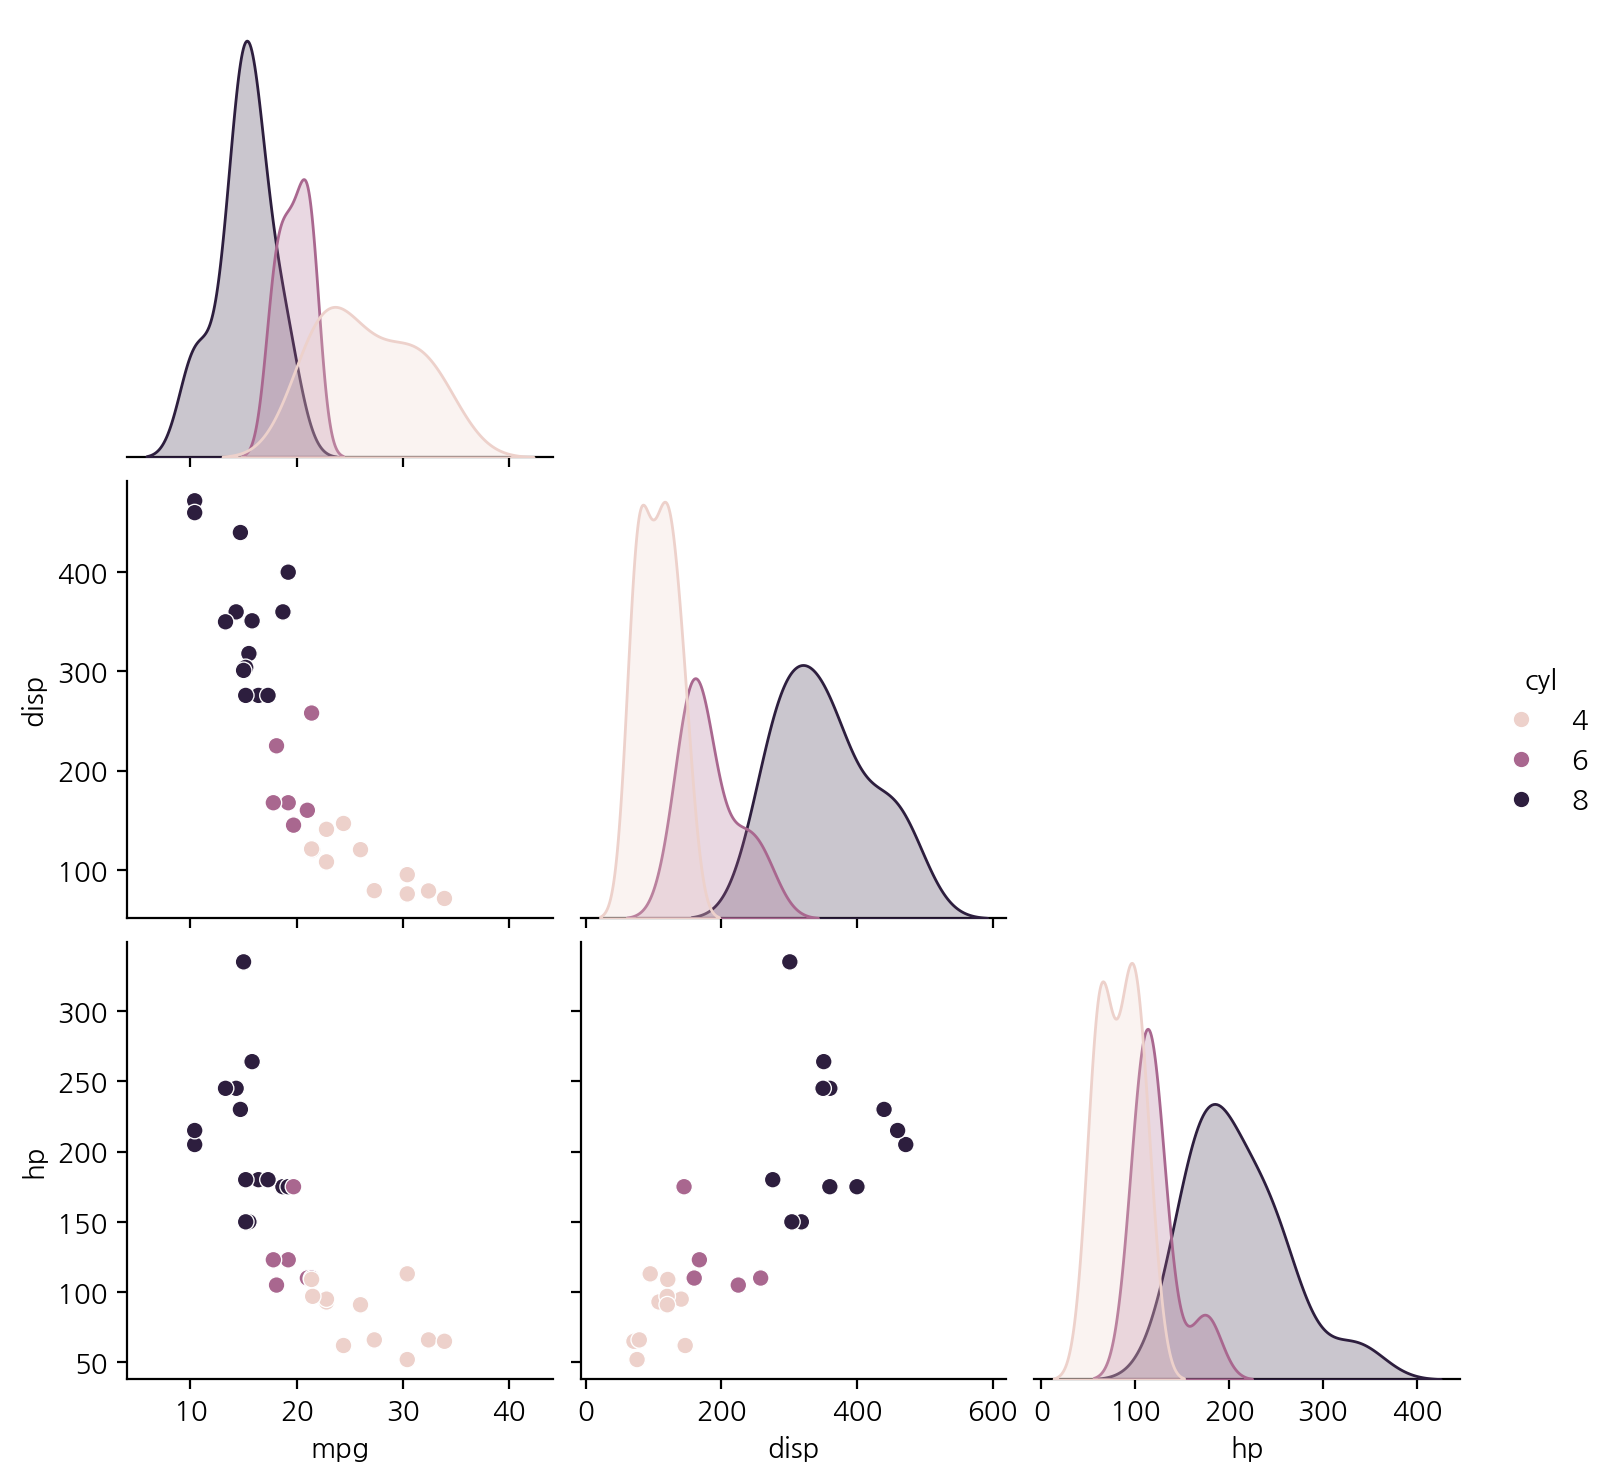

In [ ]:
sns.pairplot(mincars, diag_kind ='kde', corner=True, hue='cyl');

In [ ]:
iris - sns.load_dataset("iris")
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [ ]:
import pandas as pd

In [ ]:
pd.set_option ('display.precision', 2)

In [ ]:
corr = iris[iris.columns[:-1].tolist()].corr()
corr

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.00,-0.12,0.87,0.82
Sepal.Width,-0.12,1.00,-0.43,-0.37
Petal.Length,0.87,-0.43,1.00,0.96
Petal.Width,0.82,-0.37,0.96,1.00


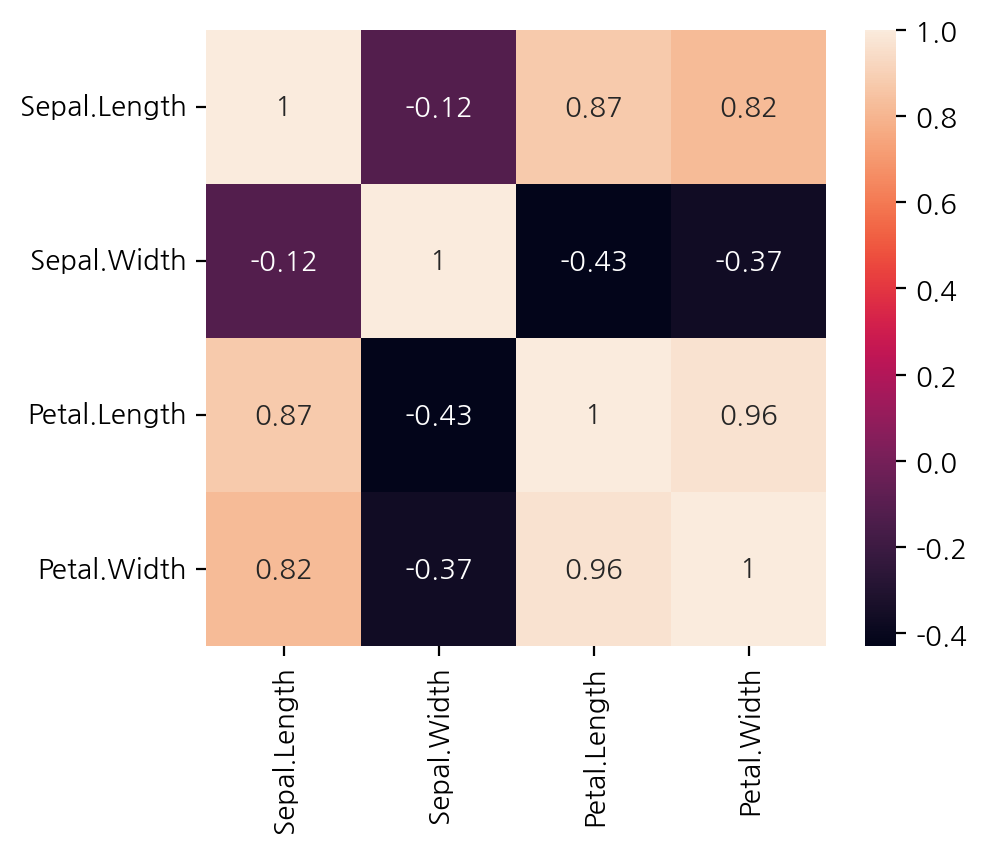

In [ ]:
sns.heatmap(corr, annot=True);

<Axes: >

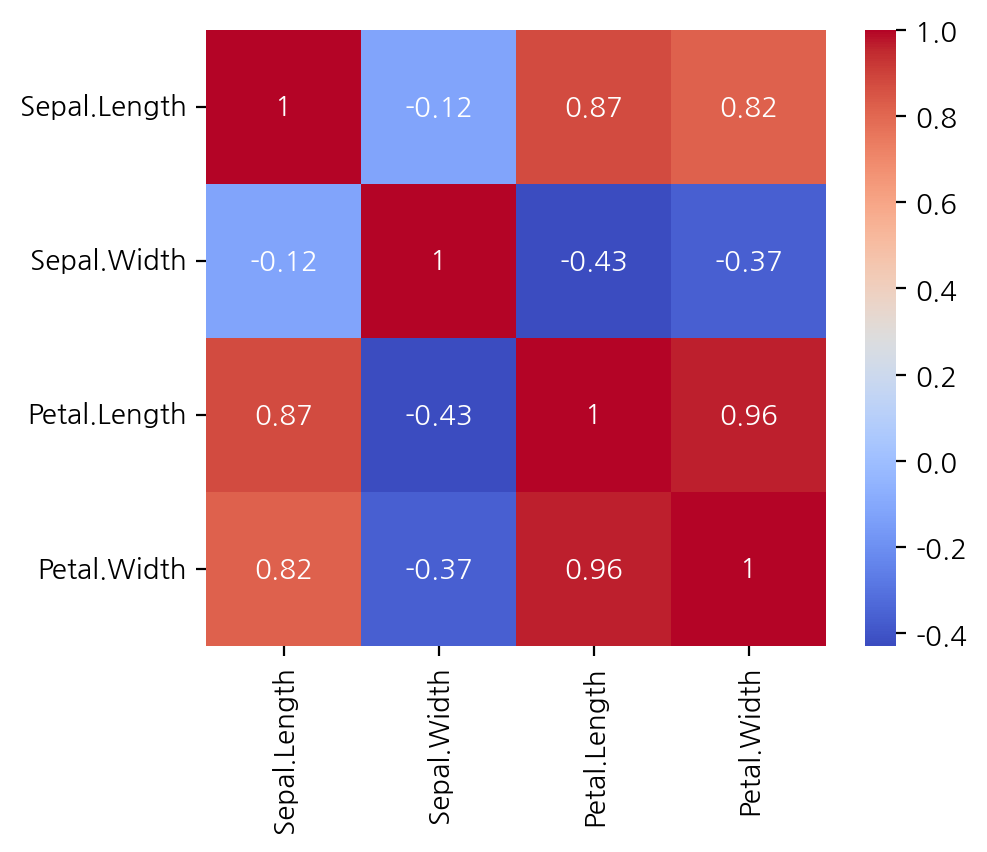

In [ ]:
sns.heatmap(corr, cmap = 'coolwarm', annot = True)

<Axes: >

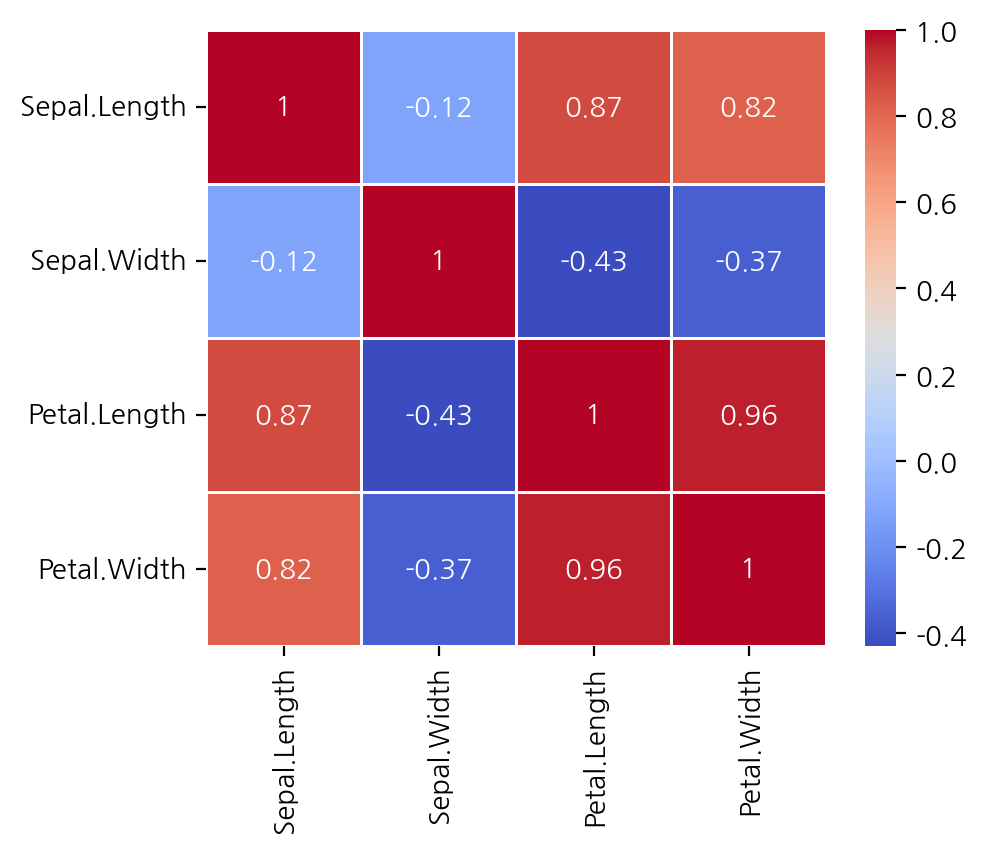

In [ ]:
sns.heatmap(corr, cmap = 'coolwarm', annot = True, linewidth = 0.5)

<Axes: >

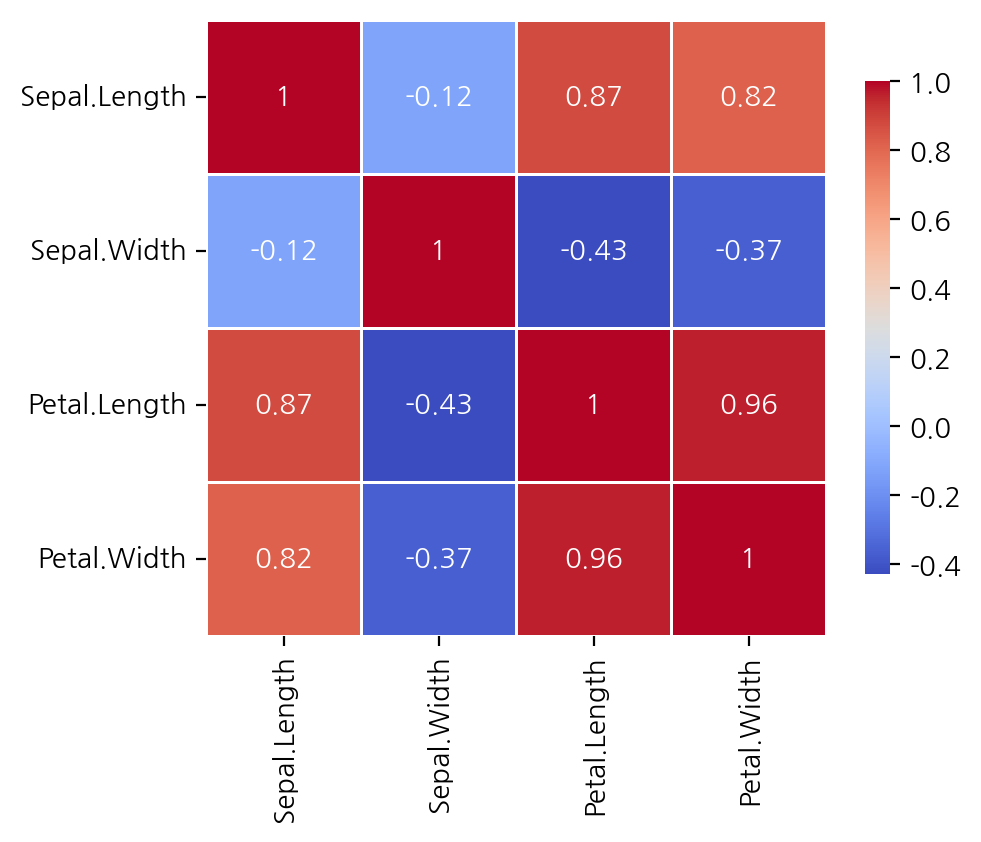

In [ ]:
sns.heatmap(corr, cmap = 'coolwarm', annot = True, linewidth = 0.5, cbar_kws={'shrink' :  0.8})

In [ ]:
mask = np.zeros_like(corr)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [ ]:
mask[np.triu_indices_from(mask)] = 1
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [ ]:
mask_new = mask[1:, :-1]
mask_new

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [ ]:
corr_iris_new  = corr.iloc[1:, :-1]
corr_iris_new

,Sepal.Length,Sepal.Width,Petal.Length
Sepal.Width,-0.12,1.00,-0.43
Petal.Length,0.87,-0.43,1.00
Petal.Width,0.82,-0.37,0.96


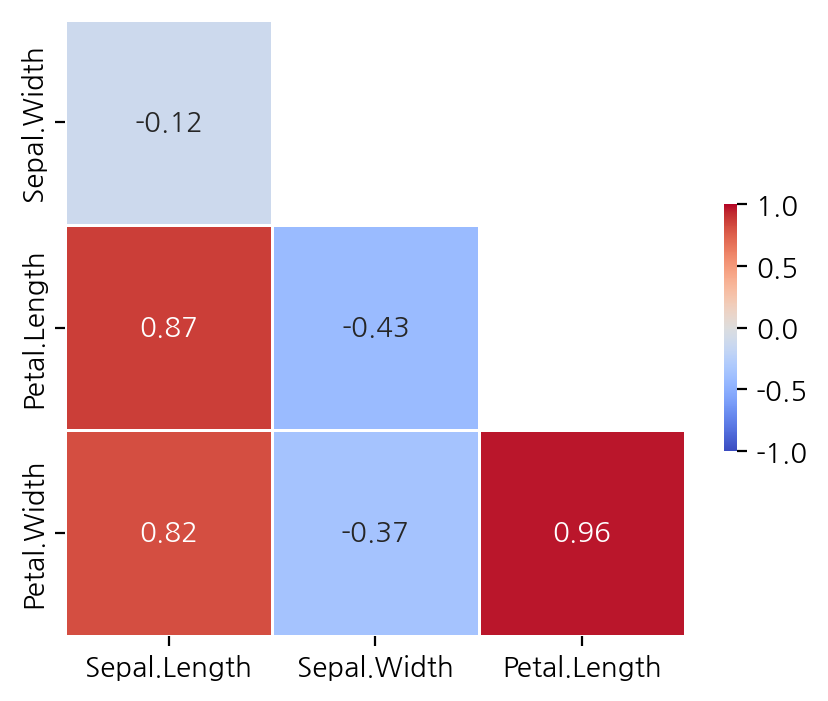

In [ ]:
sns.heatmap(corr_iris_new, annot= True, cmap= 'coolwarm', mask = mask_new,
                                           annot_kws = {"size": 10 }, vmin= -1, vmax = 1,
           cbar_kws = { "shrink" : .4},
           linewidths = .5);

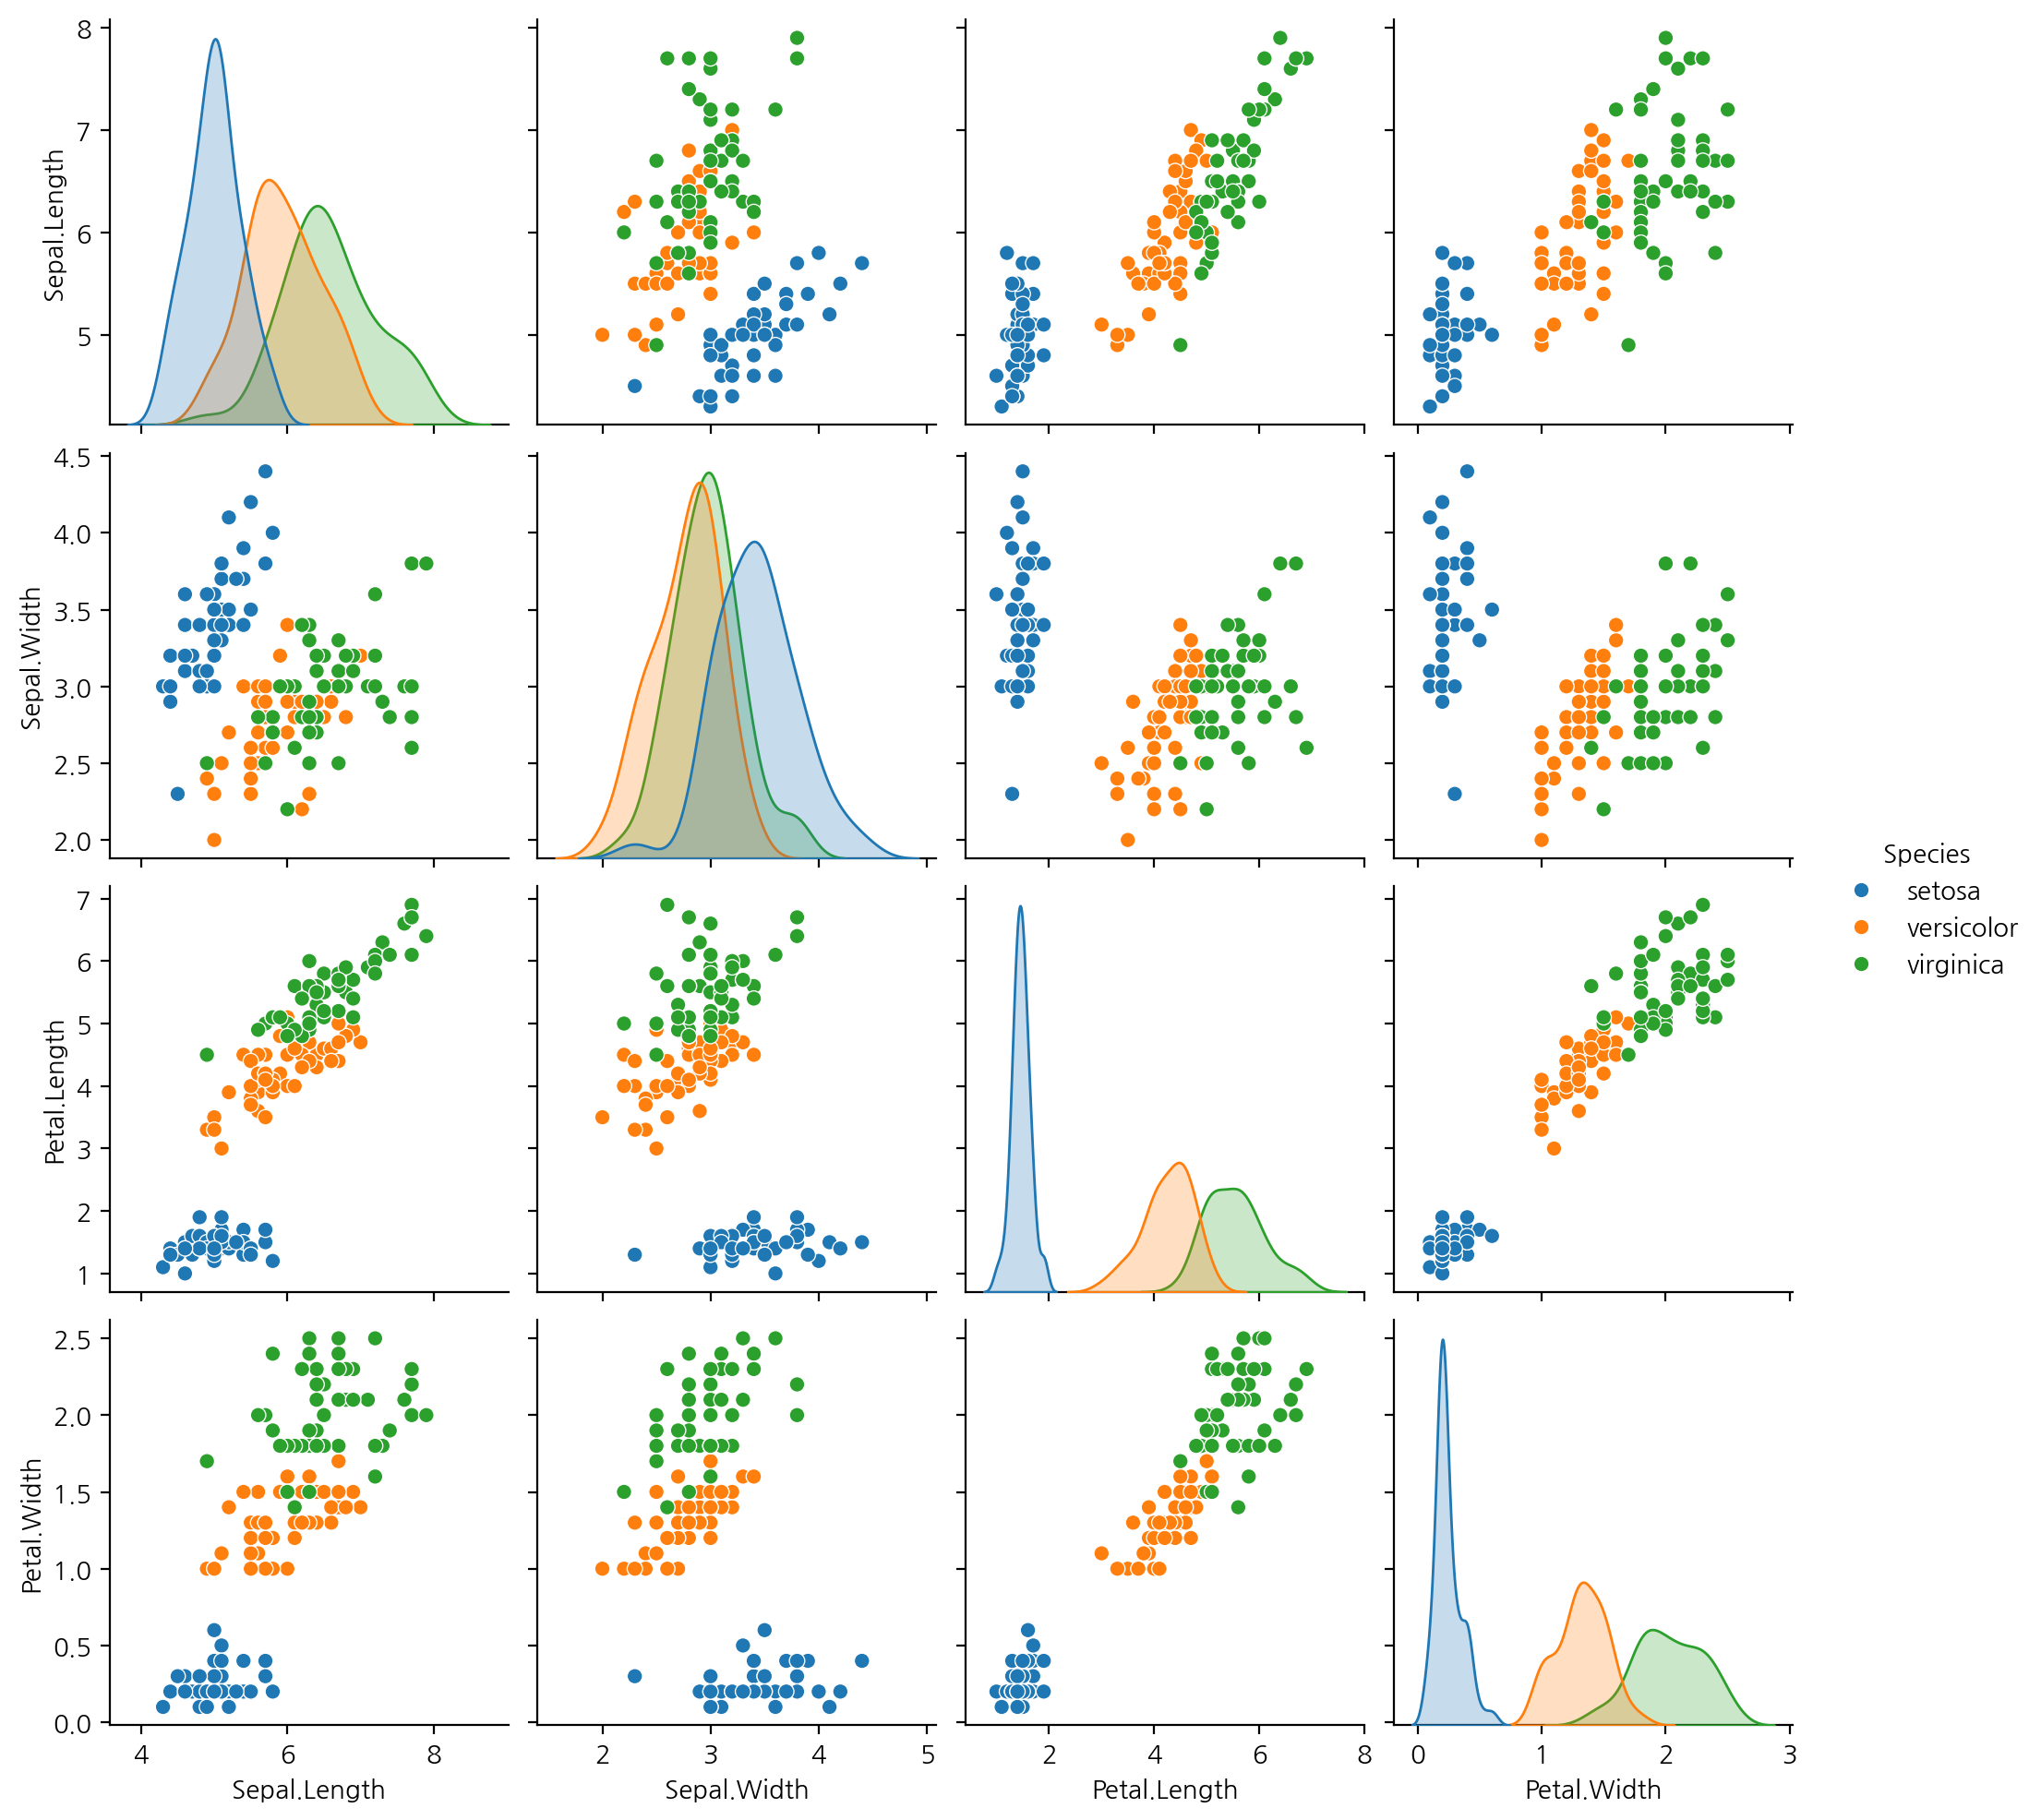

In [ ]:
sns.pairplot(iris, hue = 'Species')

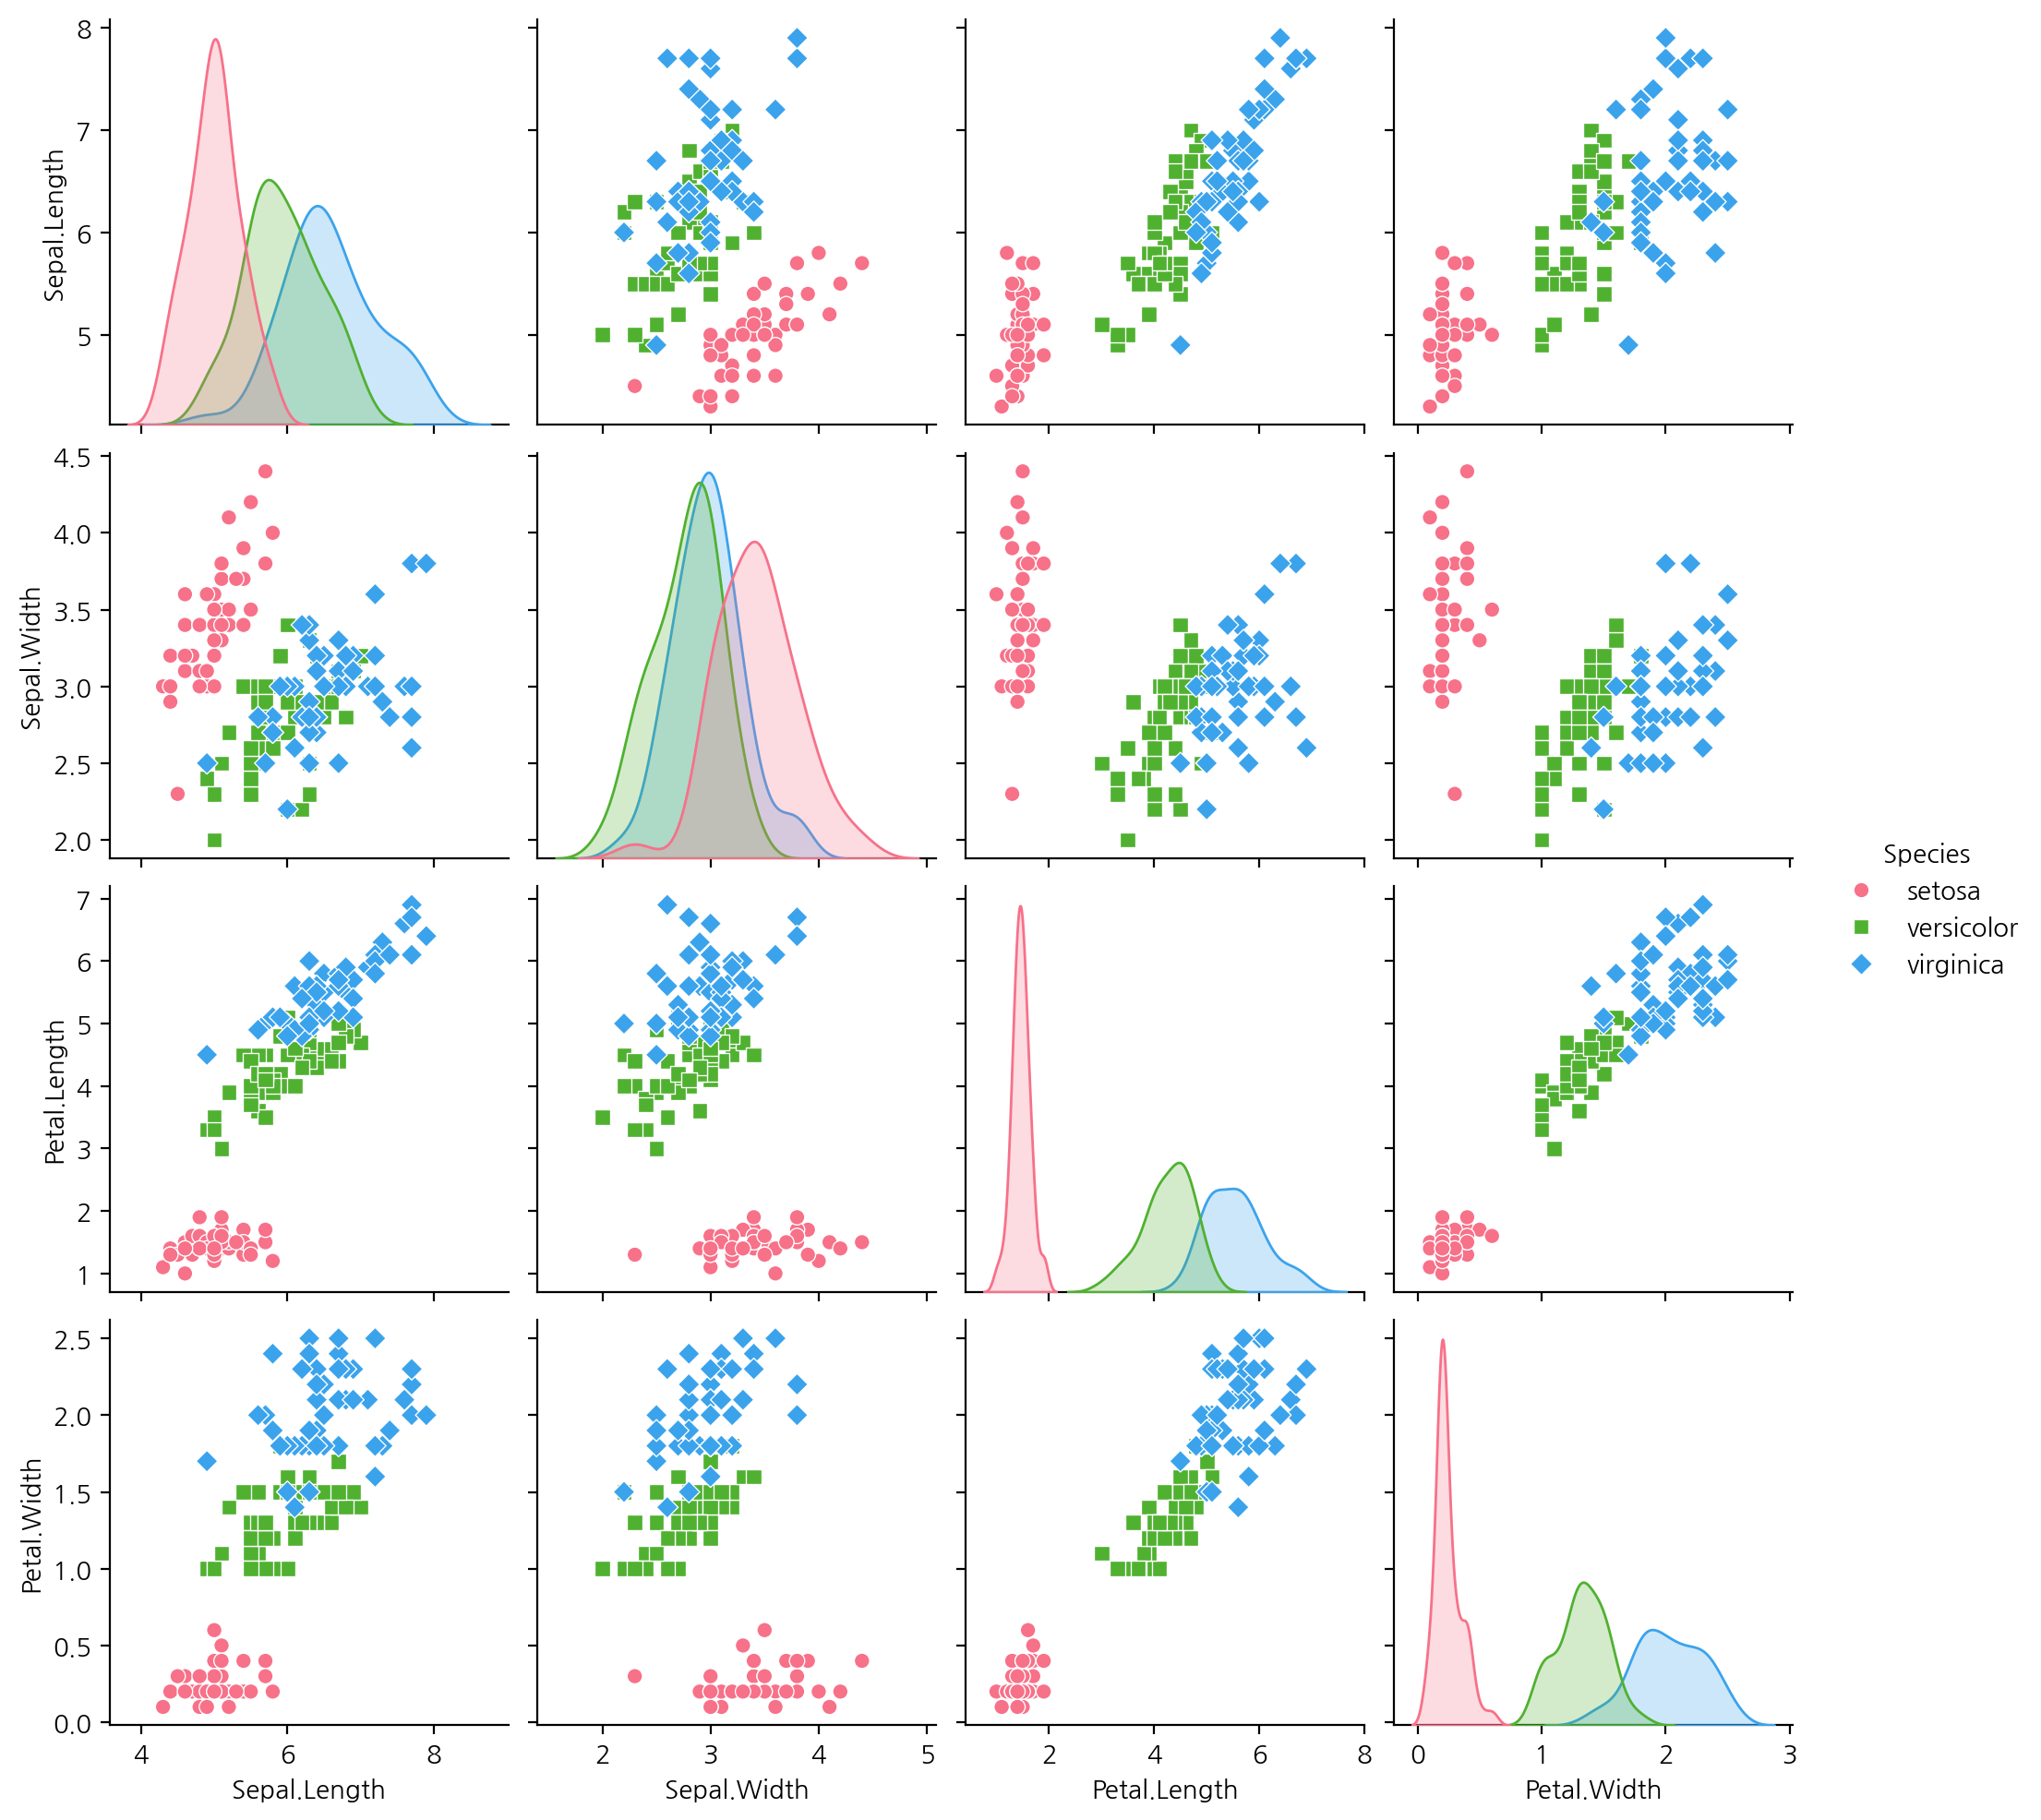

In [ ]:
sns.pairplot(iris, hue="Species" , palette= "husl" , markers=["o", "s", "D"]);


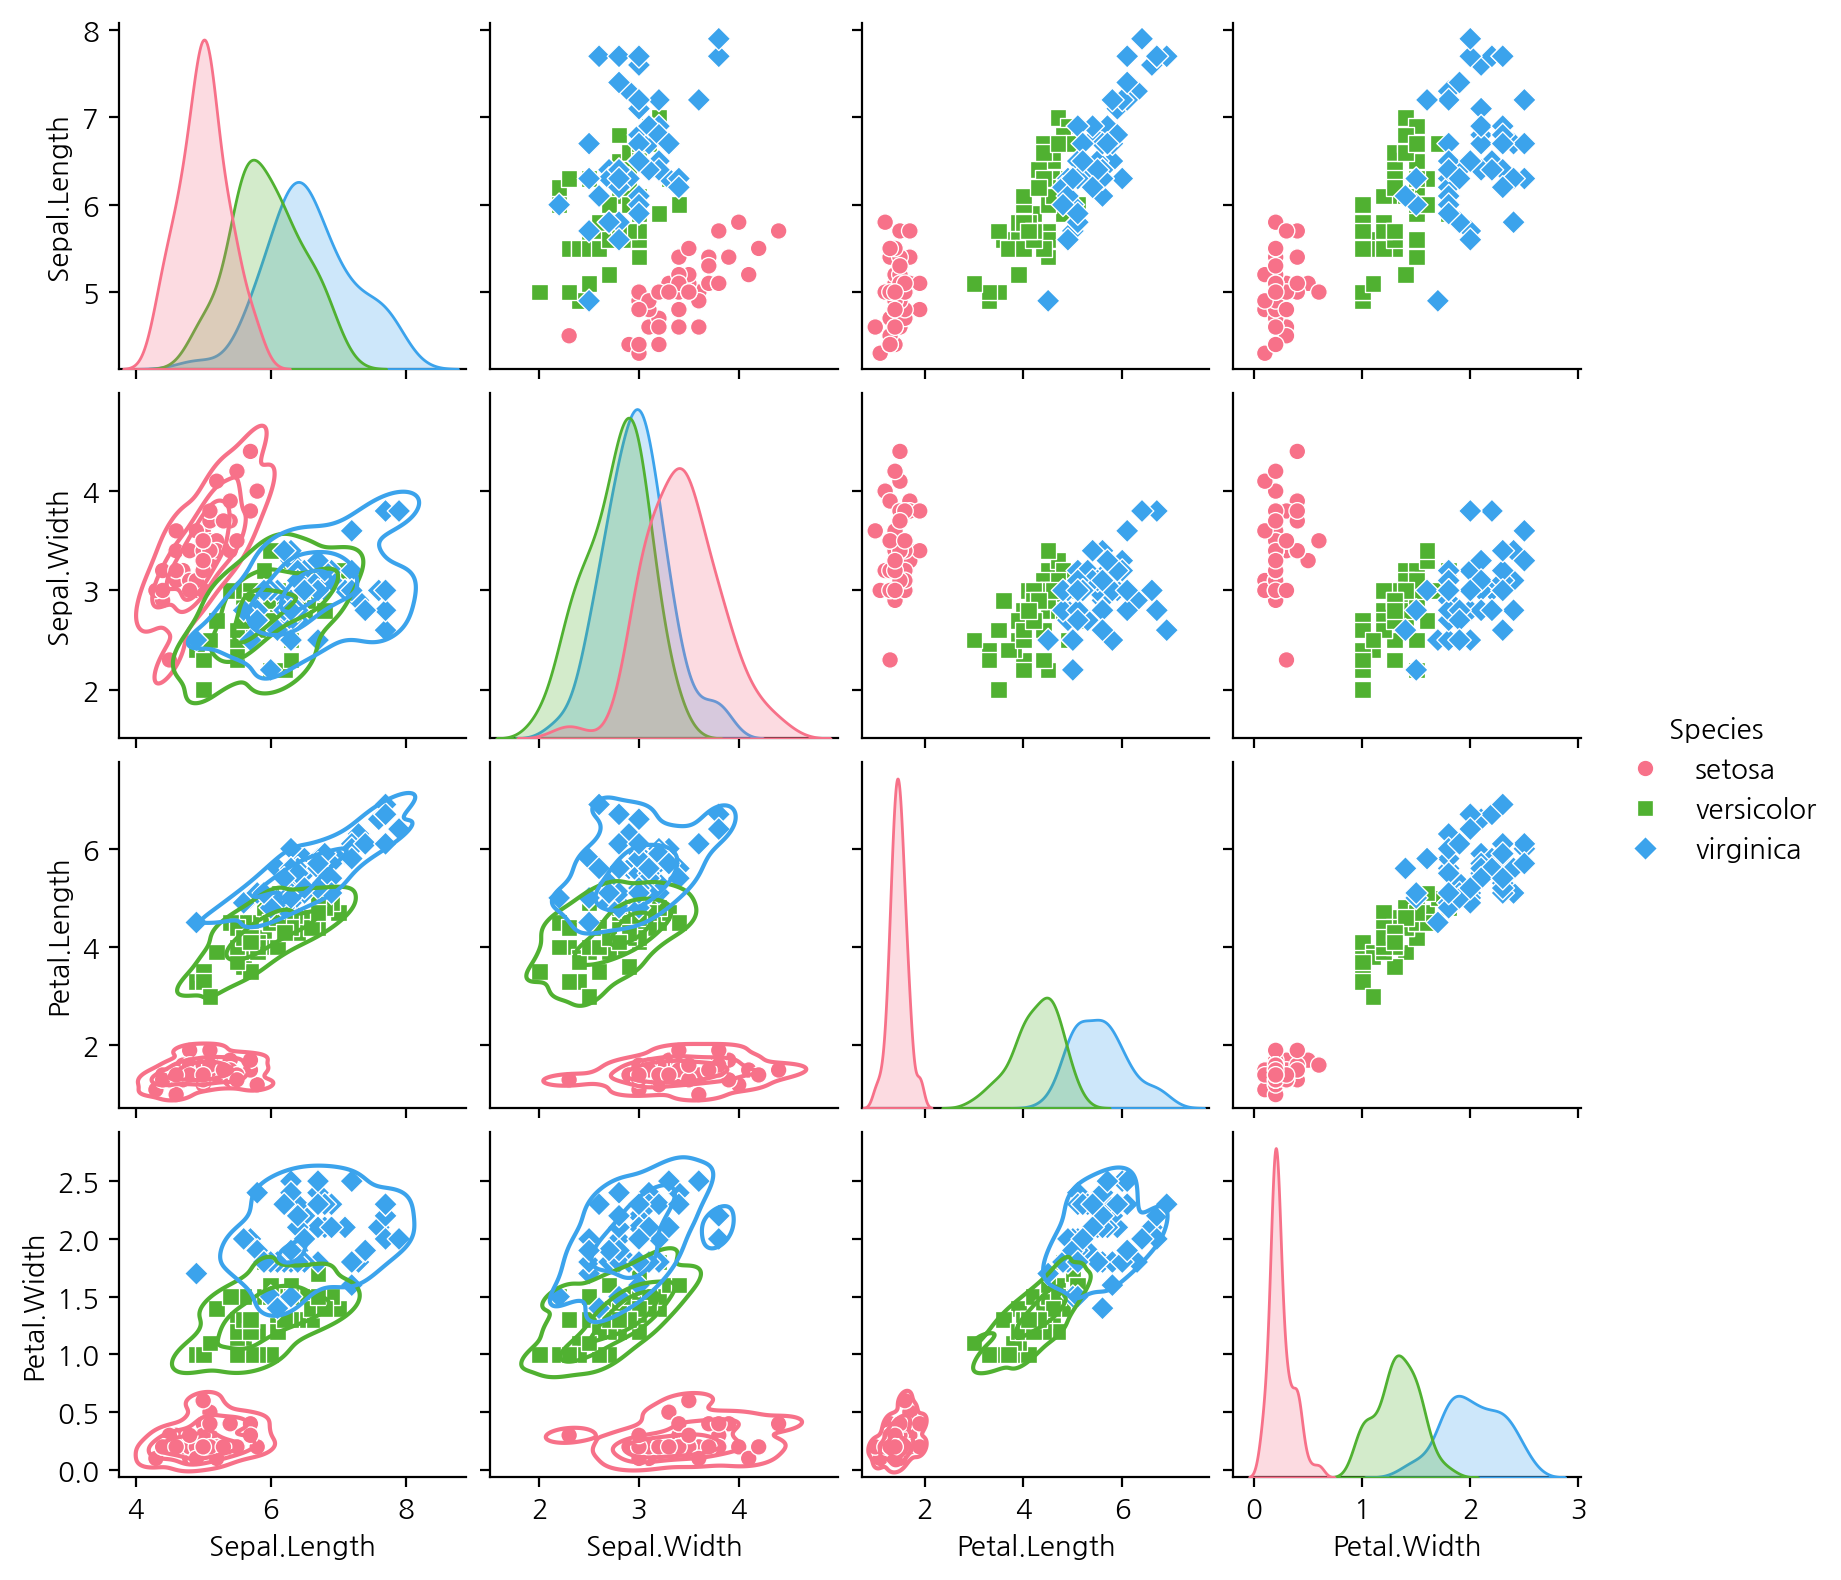

In [ ]:
g  = sns.pairplot(iris, hue = "Species",
                  palette = 'husl', height = 2.0,
                  markers = ["o", "s" , "D"]);
g.map_lower(sns.kdeplot, levels =4,
                              color = ",2")

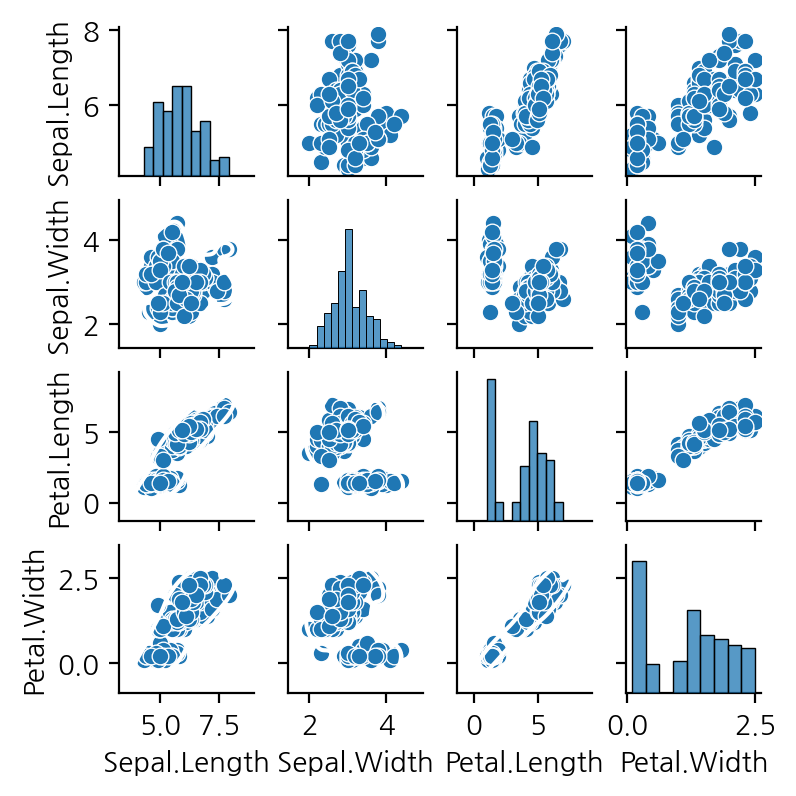

In [ ]:
g = sns.pairplot(iris, height = 1)
g.map_lower(sns.kdeplot, levels= 2 , color= "1")